In [1]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import string
from scipy.ndimage import gaussian_filter1d
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import os
from scipy.optimize import least_squares
from scipy.stats import pearsonr, spearmanr
from scipy.optimize import curve_fit
from mpl_toolkits.axes_grid1 import make_axes_locatable
from cycler import cycler
from matplotlib.colors import LogNorm
import warnings
import itertools
warnings.filterwarnings('ignore')
import sys
from PIL import Image
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
sys.path.append('BLOCKING')
from main import BlockAnalysis
import mdtraj as md  # for sasa 

plt.rcParams['xtick.top'] = True      
plt.rcParams['ytick.right'] = True   
plt.rcParams['xtick.direction'] = 'in' 
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 7.5
plt.rcParams['font.family'] = 'Arial'

cmap = plt.get_cmap("tab10")

blue2 = (0.020, 0.380, 0.670)
red2 =  (0.980, 0.000, 0.230) 
orange = (1.000, 0.500, 0.000)

# Convergence check

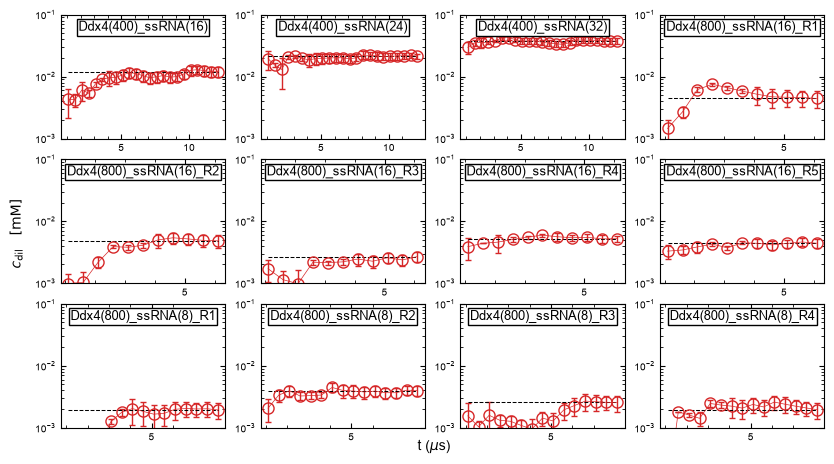

In [2]:
# convergence check using time-blocking
# c_sat accumulative average
# equibriation 1 us is removed
# DDX4 + ssRNA

start = 0 


def check_csat_convergence(ax, name, is_RNA=True, title_fontsize=9, start=start, title=''):         
    comp = "ss_acug24"
    rna_dil_conc_frame = np.load(path+"dilute_conc_frame_{0}_{1}.npy".format(name,comp))[start:]

    # perform time blocking 
    xs = []
    ys = []
    yerrs = []
    skip = 50 # 10*10 ns = 100 ns 
    for i in range(100, len(rna_dil_conc_frame)+skip, skip):
        dil_conc_segment = rna_dil_conc_frame[:i]
        block_dil = BlockAnalysis(dil_conc_segment) 
        block_dil.SEM()
        segment_mean = np.mean(dil_conc_segment)
        segment_sem = block_dil.sem
        ys.append(segment_mean)
        yerrs.append(segment_sem)
        xs.append(0.01*i + 0.1)  # in micro second
    
    ax.errorbar(xs, ys, yerrs, lw=0.5, marker='o', ms=8, elinewidth=1, capsize=2, capthick=1,
                markerfacecolor='none', color=cmap(3)) 
    #ax.plot(xs, yerrs, lw=0.5, marker='o', markerfacecolor='none', color=cmap(3)) 

    
    ax.hlines(np.mean(rna_dil_conc_frame, axis=0), np.min(xs), np.max(xs), linestyle='dashed', color='k', lw=0.75)
    #ax.set_xlim([np.min(ts_mus), np.max(ts_mus)])
    ax.set_ylim([1e-3, 1e-1])
    ax.set_yscale('log')
    ax.text(0.5, 0.95, title, ha='center', va='top', transform=ax.transAxes, fontsize=title_fontsize,
           bbox=dict(boxstyle="square,pad=0.15", facecolor="white", edgecolor="black", linewidth=1))

path = './analysis/data/'

fig, axs = plt.subplots(3,4,figsize=(8,4.5))
axs = axs.flat


ax = axs[0]
check_csat_convergence(ax, "DDX4-400_ss_acug24-16", title="Ddx4(400)_ssRNA(16)")

ax = axs[1]
check_csat_convergence(ax, "DDX4-400_ss_acug24-24", title="Ddx4(400)_ssRNA(24)")

ax = axs[2]
check_csat_convergence(ax, "DDX4-400_ss_acug24-32", title="Ddx4(400)_ssRNA(32)")

ax = axs[3]
check_csat_convergence(ax, "DDX4-800_ss_acug24-16_1", title="Ddx4(800)_ssRNA(16)_R1")

ax = axs[4]
check_csat_convergence(ax, "DDX4-800_ss_acug24-16_2", title="Ddx4(800)_ssRNA(16)_R2")

ax = axs[5]
check_csat_convergence(ax, "DDX4-800_ss_acug24-16_3", title="Ddx4(800)_ssRNA(16)_R3")

ax = axs[6]
check_csat_convergence(ax, "DDX4-800_ss_acug24-16_4", title="Ddx4(800)_ssRNA(16)_R4")

ax = axs[7]
check_csat_convergence(ax, "DDX4-800_ss_acug24-16_5", title="Ddx4(800)_ssRNA(16)_R5")

ax = axs[8]
check_csat_convergence(ax, "DDX4-800_ss_acug24-8_1", title="Ddx4(800)_ssRNA(8)_R1")

ax = axs[9]
check_csat_convergence(ax, "DDX4-800_ss_acug24-8_2", title="Ddx4(800)_ssRNA(8)_R2")

ax = axs[10]
check_csat_convergence(ax, "DDX4-800_ss_acug24-8_3", title="Ddx4(800)_ssRNA(8)_R3")

ax = axs[11]
check_csat_convergence(ax, "DDX4-800_ss_acug24-8_4", title="Ddx4(800)_ssRNA(8)_R4")

#for ax in axs[-3:]:
#    ax.axis("off")

for ax in axs[0:3]:
    ax.set_xticks(np.arange(5,12,5)); ax.set_xticks(np.arange(1,12,1),minor=True)
for ax in axs[3:10]:
    ax.set_xticks(np.arange(5,6.1,5)); ax.set_xticks(np.arange(1,6.1,1),minor=True)
for ax in axs[10:]:
    ax.set_xticks(np.arange(5,8,5)); ax.set_xticks(np.arange(1,8,1),minor=True)

    
fig.supxlabel("t ($\mu$s)", fontsize=10)
fig.text(-0.03, 0.5, "$c_{\mathrm{dil}}~~~\mathrm{[mM]}$", rotation=90, fontsize=10, va='center')

plt.tight_layout(pad=0.1)
plt.savefig("sup_cdil_ddx4_ssrna.pdf", dpi=300, bbox_inches='tight')

plt.show()




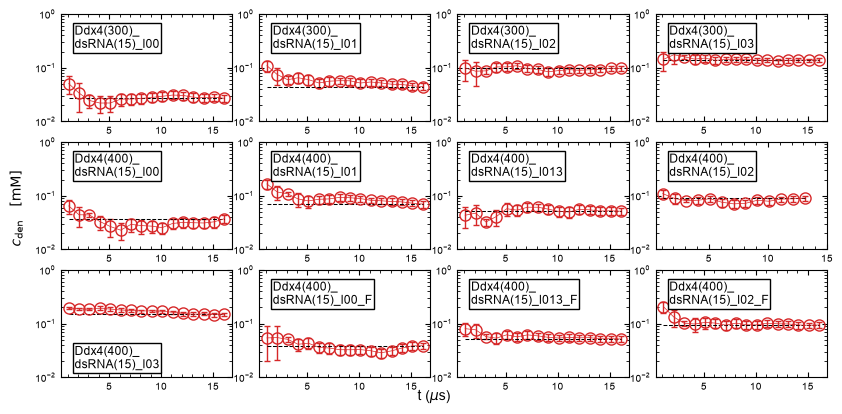

In [3]:
# convergence check 
# c_sat accumulative average
# equibriation 1 us is removed
# DDX4 + dsRNA

start = 0 

def check_csat_convergence(ax, name, is_RNA=True, title_fontsize=8.5, start=start, title='', title_x=0.08, title_y=0.9):

    comp = "ds_acug24"
    rna_den_conc_frame = np.load(path+"dense_conc_frame_{0}_{1}.npy".format(name,comp))[start:]

    # perform time blocking 
    xs = []
    ys = []
    yerrs = []
    skip = 100 # 10*10 ns = 100 ns 
    for i in range(100, len(rna_den_conc_frame)+skip, skip):
        den_conc_segment = rna_den_conc_frame[:i]
        block_den = BlockAnalysis(den_conc_segment) 
        block_den.SEM()
        segment_mean = np.mean(den_conc_segment)
        segment_sem = block_den.sem
        ys.append(segment_mean)
        yerrs.append(segment_sem)
        xs.append(0.01*i + 0.1)  # in micro second
    
    ax.errorbar(xs, ys, yerrs, lw=0.5, marker='o', ms=8, elinewidth=1, capsize=2, capthick=1,
                markerfacecolor='none', color=cmap(3)) 
    
    ax.hlines(np.mean(rna_den_conc_frame, axis=0), np.min(xs), np.max(xs), linestyle='dashed', color='k', lw=0.75)
    ax.set_ylim([1e-2, 1e0])
    ax.set_yscale('log')
    ax.text(title_x, title_y, title, ha='left', va='top', transform=ax.transAxes, fontsize=title_fontsize,
           bbox=dict(boxstyle="square,pad=0.15", facecolor="white", edgecolor="black", linewidth=1))


path = './analysis/data/'

fig, axs = plt.subplots(3,4,figsize=(8,4))
axs = axs.flat

ax = axs[0]
check_csat_convergence(ax, "DDX4-300_ds_acug24-15_direct_l00", title="Ddx4(300)_\ndsRNA(15)_l00")

ax = axs[1]
check_csat_convergence(ax, "DDX4-300_ds_acug24-15_direct_l01", title="Ddx4(300)_\ndsRNA(15)_l01")

ax = axs[2]
check_csat_convergence(ax, "DDX4-300_ds_acug24-15_direct_l02", title="Ddx4(300)_\ndsRNA(15)_l02")

ax = axs[3]
check_csat_convergence(ax, "DDX4-300_ds_acug24-15_direct_l03", title="Ddx4(300)_\ndsRNA(15)_l03")

ax = axs[4]
check_csat_convergence(ax, "DDX4-400_ds_acug24-15_direct_l00", title="Ddx4(400)_\ndsRNA(15)_l00")

ax = axs[5]
check_csat_convergence(ax, "DDX4-400_ds_acug24-15_direct_l01", title="Ddx4(400)_\ndsRNA(15)_l01")

ax = axs[6]
check_csat_convergence(ax, "DDX4-400_ds_acug24-15_direct_l013", title="Ddx4(400)_\ndsRNA(15)_l013")

ax = axs[7]
check_csat_convergence(ax, "DDX4-400_ds_acug24-15_direct_l02", title="Ddx4(400)_\ndsRNA(15)_l02")

ax = axs[8]
check_csat_convergence(ax, "DDX4-400_ds_acug24-15_direct_l03", title="Ddx4(400)_\ndsRNA(15)_l03", title_y=0.3)

ax = axs[9]
check_csat_convergence(ax, "DDX4-400_ds_acug24-15_direct_l01_k10", title="Ddx4(400)_\ndsRNA(15)_l00_F")

ax = axs[10]
check_csat_convergence(ax, "DDX4-400_ds_acug24-15_direct_l013_k10", title="Ddx4(400)_\ndsRNA(15)_l013_F")

ax = axs[11]
check_csat_convergence(ax, "DDX4-400_ds_acug24-15_direct_l02_k10", title="Ddx4(400)_\ndsRNA(15)_l02_F")

fig.supxlabel("t ($\mu$s)", fontsize=10)
fig.text(-0.03, 0.5, "$c_{\mathrm{den}}~~~\mathrm{[mM]}$", rotation=90, fontsize=10, va='center')
for ax in axs:
    ax.set_xticks(np.arange(5,16,5)); ax.set_xticks(np.arange(1,16,1),minor=True)

plt.tight_layout(pad=0.1)

plt.savefig("sup_cden_DDX4_dsRNA.pdf",dpi=300, bbox_inches='tight')

plt.show()



In [4]:
# convergence check 
# c_sat accumulative average
# equibriation 1 us is removed
# CAPRIN 1

start = 0 
path = './analysis/data/'

def get_caprin1_systems_name(name):
    if name == "CAPRIN1_N623TN630T-500_sspolyR12-500_dspolyR12-15_200mM":
        print("loading",name)
        caprin = "CAPRIN1_N623TN630T"
        rna = "sspolyR12"
        rna_client = "dspolyR12"
        title = "CAPRIN1 \ndsRNA_200mM"
        
    elif name == "CAPRIN1_N623TN630T-500_sspolyR12-500_label_sspolyR12-30_200mM":
        print("loading",name)
        caprin = "CAPRIN1_N623TN630T"
        rna = "sspolyR12"
        rna_client = "label_sspolyR12"
        title = "CAPRIN1 \nssRNA_200mM"
    
    elif name == "CAPRIN1_N623TN630T-500_sspolyR12-500_dspolyR12-15_80mM":
        print("loading",name)
        caprin = "CAPRIN1_N623TN630T"
        rna = "sspolyR12"
        rna_client = "dspolyR12"
        title = "CAPRIN1 \ndsRNA_80mM"
        
    elif name == "CAPRIN1_N623TN630T-500_sspolyR12-500_label_sspolyR12-30_80mM":
        print("loading",name)
        caprin = "CAPRIN1_N623TN630T"
        rna = "sspolyR12"
        rna_client = "label_sspolyR12"
        title = "CAPRIN1 \nssRNA_80mM"
        
    elif name == "CAPRIN1_N623TN630T-500_sspolyR12-500_dspolyR12-15_100mM":
        print("loading",name)
        caprin = "CAPRIN1_N623TN630T"
        rna = "sspolyR12"
        rna_client = "dspolyR12"
        title = "CAPRIN1 \ndsRNA_100mM"
        
    elif name == "CAPRIN1_N623TN630T-500_sspolyR12-500_label_sspolyR12-30_100mM":
        print("loading",name)
        caprin = "CAPRIN1_N623TN630T"
        rna = "sspolyR12"
        rna_client = "label_sspolyR12"
        title = "CAPRIN1 \nssRNA_100mM"
        
    elif name == "CAPRIN1_N623TN630T_RK-500_sspolyR12-500_dspolyR12-15_80mM":
        print("loading",name)
        caprin = "CAPRIN1_N623TN630T_RK"
        rna = "sspolyR12"
        rna_client = "dspolyR12"
        title = "CAPRIN1-RK \ndsRNA_80mM"
        
    elif name == "CAPRIN1_N623TN630T_RK-500_sspolyR12-500_label_sspolyR12-30_80mM":
        print("loading",name)
        caprin = "CAPRIN1_N623TN630T_RK"
        rna = "sspolyR12"
        rna_client = "label_sspolyR12"
        title = "CAPRIN1-RK \nssRNA_80mM"
        
    else:
        print("check file name")

    return caprin, rna, rna_client, title


def check_csat_convergence(ax, name, title_fontsize=8, start=start, title_x=0.95, title_y=0.9):

    caprin, rna, rna_client, title = get_caprin1_systems_name(name)
    rna_dil_conc_frame = np.load(path+"dilute_conc_frame_{0}_{1}.npy".format(name,rna_client))[start:]
    
    # perform time blocking 
    xs = []
    ys = []
    yerrs = []
    skip = 50 # 10*10 ns = 100 ns 
    for i in range(100, len(rna_dil_conc_frame)+skip, skip):
        #print(i)
        dil_conc_segment = rna_dil_conc_frame[:i]
        block_dil = BlockAnalysis(dil_conc_segment) 
        block_dil.SEM()
        segment_mean = np.mean(dil_conc_segment)
        segment_sem = block_dil.sem
        ys.append(segment_mean)
        yerrs.append(segment_sem)
        xs.append(0.01*i + 0.1)  # in micro second

    if rna_client == "label_sspolyR12":
        color = cmap(2)
    else: 
        color = 'k'
    ax.errorbar(xs, ys, yerrs, lw=0.5, marker='o', ms=8, elinewidth=1, capsize=2, capthick=1,
                markerfacecolor='none', color=color) 
    
    ax.hlines(np.mean(rna_dil_conc_frame, axis=0), np.min(xs), np.max(xs), linestyle='dashed', color='k')
    ax.set_ylim([1e-4, 1e0])
    ax.set_yscale('log')

    #print(rna_dil_conc_frame[-500:])

    
    ax.text(title_x, title_y, title, ha='right', va='top', transform=ax.transAxes, fontsize=title_fontsize,
           bbox=dict(boxstyle="square,pad=0.15", facecolor="white", edgecolor="black", linewidth=1))


loading CAPRIN1_N623TN630T-500_sspolyR12-500_dspolyR12-15_200mM
loading CAPRIN1_N623TN630T-500_sspolyR12-500_label_sspolyR12-30_200mM
loading CAPRIN1_N623TN630T-500_sspolyR12-500_dspolyR12-15_100mM
loading CAPRIN1_N623TN630T-500_sspolyR12-500_label_sspolyR12-30_100mM
loading CAPRIN1_N623TN630T-500_sspolyR12-500_dspolyR12-15_80mM
loading CAPRIN1_N623TN630T-500_sspolyR12-500_label_sspolyR12-30_80mM
loading CAPRIN1_N623TN630T_RK-500_sspolyR12-500_dspolyR12-15_80mM
loading CAPRIN1_N623TN630T_RK-500_sspolyR12-500_label_sspolyR12-30_80mM


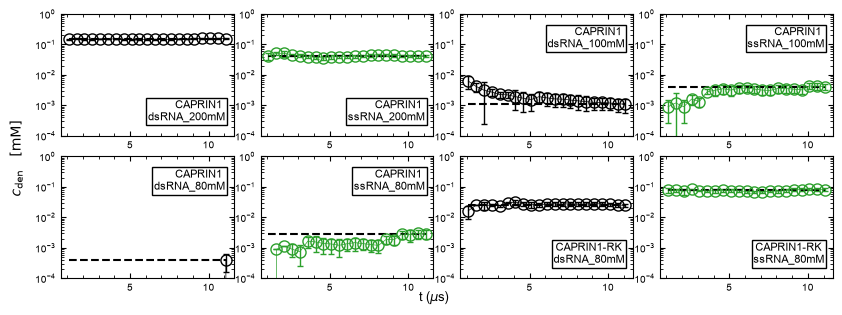

In [5]:
fig, axs = plt.subplots(2,4,figsize=(8,3))
axs = axs.flat

ax = axs[0]
check_csat_convergence(ax, "CAPRIN1_N623TN630T-500_sspolyR12-500_dspolyR12-15_200mM", title_y=0.3)

ax = axs[1]
check_csat_convergence(ax, "CAPRIN1_N623TN630T-500_sspolyR12-500_label_sspolyR12-30_200mM", title_y=0.3)

ax = axs[2]
check_csat_convergence(ax, "CAPRIN1_N623TN630T-500_sspolyR12-500_dspolyR12-15_100mM")

ax = axs[3]
check_csat_convergence(ax, "CAPRIN1_N623TN630T-500_sspolyR12-500_label_sspolyR12-30_100mM")

ax = axs[4]
check_csat_convergence(ax, "CAPRIN1_N623TN630T-500_sspolyR12-500_dspolyR12-15_80mM")

ax = axs[5]
check_csat_convergence(ax, "CAPRIN1_N623TN630T-500_sspolyR12-500_label_sspolyR12-30_80mM")

ax = axs[6]
check_csat_convergence(ax, "CAPRIN1_N623TN630T_RK-500_sspolyR12-500_dspolyR12-15_80mM", title_y=0.3)

ax = axs[7]
check_csat_convergence(ax, "CAPRIN1_N623TN630T_RK-500_sspolyR12-500_label_sspolyR12-30_80mM", title_y=0.3)

fig.supxlabel("t ($\mu$s)")
fig.text(-0.03, 0.5, "$c_{\mathrm{den}}~~~\mathrm{[mM]}$", rotation=90, fontsize=10, va='center')
for ax in axs:
    ax.set_xticks(np.arange(5,12,5)); ax.set_xticks(np.arange(1,12,1),  minor=True)
    
plt.tight_layout(pad=0.1)
plt.savefig("sup_cdil_caprin1.pdf", dpi=300, bbox_inches='tight')

plt.show()

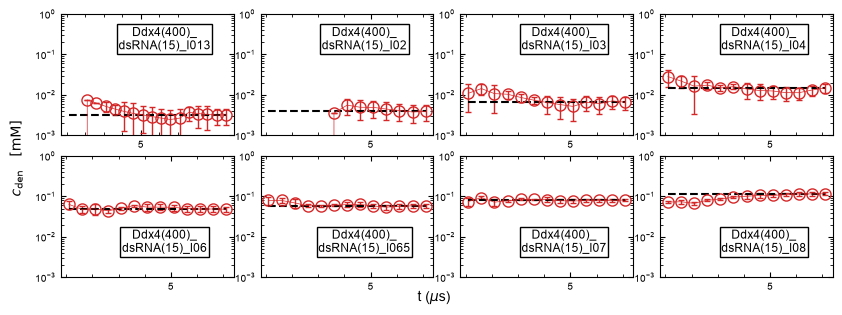

In [6]:
# convergence check 
# c_sat accumulative average
# equibriation 1 us is removed
# DDX4 + DNA

start = 0 

def check_csat_convergence(ax, name, title_fontsize=8.5, start=start, title='', title_x=0.6, title_y=0.9):
    comp = "dsACTG24"
    rna_conc_frame = np.load(path+"dense_conc_frame_{0}_{1}.npy".format(name,comp))[start:]

    # perform time blocking 
    xs = []
    ys = []
    yerrs = []
    skip = 50 # 10*10 ns = 100 ns 
    for i in range(100, len(rna_conc_frame)+skip, skip):
        conc_segment = rna_conc_frame[:i]
        block = BlockAnalysis(conc_segment) 
        block.SEM()
        segment_mean = np.mean(conc_segment)
        segment_sem = block.sem
        ys.append(segment_mean)
        yerrs.append(segment_sem)
        xs.append(0.01*i + 0.1)  # in micro second
    
    ax.errorbar(xs, ys, yerrs, lw=0.5, marker='o', ms=8, elinewidth=1, capsize=2, capthick=1,
                markerfacecolor='none', color=cmap(3)) 
    
    ax.hlines(np.mean(rna_conc_frame, axis=0), np.min(xs), np.max(xs), linestyle='dashed', color='k')
    ax.set_ylim([1e-3, 1e0])
    ax.set_yscale('log')
    ax.text(title_x, title_y, title, ha='center', va='top', transform=ax.transAxes, fontsize=title_fontsize,
           bbox=dict(boxstyle="square,pad=0.15", facecolor="white", edgecolor="black", linewidth=1))


path = './analysis/data/'

fig, axs = plt.subplots(2,4,figsize=(8,3))
axs = axs.flat

ax = axs[0]
check_csat_convergence(ax, "DDX4-400_dsACTG24-15", title="Ddx4(400)_\ndsRNA(15)_l013")

ax = axs[1]
check_csat_convergence(ax, "DDX4-400_dsACTG24-15_l02", title="Ddx4(400)_\ndsRNA(15)_l02")

ax = axs[2]
check_csat_convergence(ax, "DDX4-400_dsACTG24-15_l03", title="Ddx4(400)_\ndsRNA(15)_l03")

ax = axs[3]
check_csat_convergence(ax, "DDX4-400_dsACTG24-15_l04", title="Ddx4(400)_\ndsRNA(15)_l04")

ax = axs[4]
check_csat_convergence(ax, "DDX4-400_dsACTG24-15_l06", title="Ddx4(400)_\ndsRNA(15)_l06", title_y=0.4)

ax = axs[5]
check_csat_convergence(ax, "DDX4-400_dsACTG24-15_l065", title="Ddx4(400)_\ndsRNA(15)_l065", title_y=0.4)

ax = axs[6]
check_csat_convergence(ax, "DDX4-400_dsACTG24-15_l07", title="Ddx4(400)_\ndsRNA(15)_l07", title_y=0.4)

ax = axs[7]
check_csat_convergence(ax, "DDX4-400_dsACTG24-15_l08", title="Ddx4(400)_\ndsRNA(15)_l08", title_y=0.4)

fig.supxlabel("t ($\mu$s)", fontsize=10)
fig.text(-0.03, 0.5, "$c_{\mathrm{den}}~~~\mathrm{[mM]}$", rotation=90, fontsize=10, va='center')
for ax in axs:
    ax.set_xticks(np.arange(5,8,5)); ax.set_xticks(np.arange(1,8,1),minor=True)

plt.tight_layout(pad=0.1)

plt.savefig("sup_cden_DDX4_dsDNA.pdf", dpi=300, bbox_inches='tight')

plt.show()



# Density Profiles 

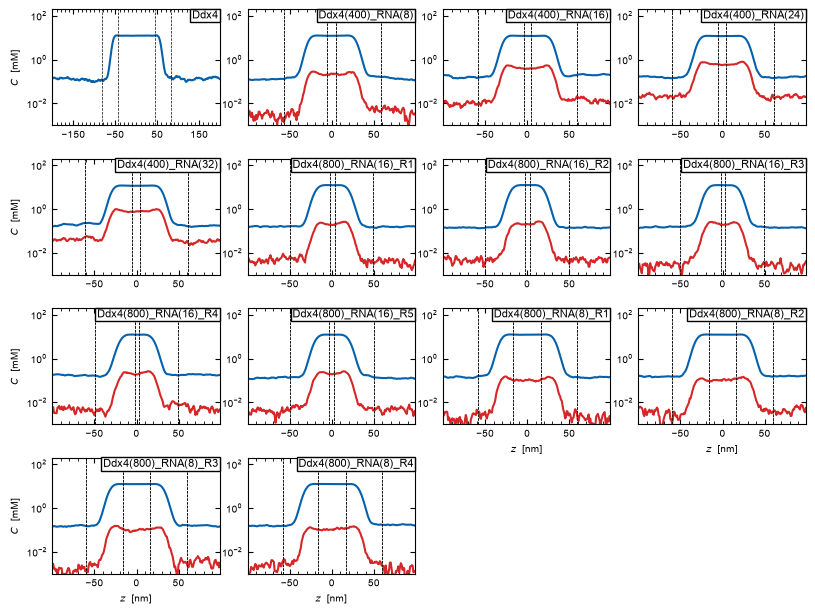

In [7]:
# density profules shown for each simulation

def ddx4_plot_density_profile_ssRNA(ax, name, comp_name, title, sdir="analysis/data/"):
    h = np.load(sdir+"hist_"+name+"_"+comp_name+'.npy')
    x = np.arange(0,len(h.mean(axis=0)))                   # bin size 1 nm
    x = x-np.mean(x)                                       # centering z=0
    
    # DDX4 in blue
    if comp_name is "DDX4":
        ax.plot(x, h.mean(axis=0), label="Ddx4", color=blue2)
    
    # RNA in red
    elif comp_name is "ss_acug24":
        ax.plot(x, h.mean(axis=0), label="ssRNA", color=cmap(3))
        
    # boundary line   
    bb = np.load(sdir+"cutoff_"+name+".npy")
    ax.vlines(bb,1e-3,2*1e2,color='black',linestyle="dashed",lw=0.5)
    
    # axis setting
    ax.set_ylim([1e-3, 2*1e2])
    ax.set_xlim([x[0], x[-1]])
    ax.set_yscale('log')
    
    ax.text(0.99, 0.99, title, ha='right', va='top', transform=ax.transAxes, fontsize=legend_fontsize, 
              bbox=dict(boxstyle="square,pad=0.15", facecolor="white", edgecolor="black", linewidth=1) )


#ax.legend(fontsize=8, loc='upper right',frameon=False) 
#ax.set_xlabel("$z$ [nm]",fontsize=8)
#ax.set_ylabel("$C$ [mM]",fontsize=8)
    


######################################################
# figure plot
fig,axs = plt.subplots(4,4,figsize=(8,6))
axs = axs.flat

legend_fontsize = 8

# DDX4 350 chains
ax = axs[0]
ddx4_plot_density_profile_ssRNA(ax, 'DDX4-350', 'DDX4', 'Ddx4') 

# DDX4 400 chains
name = "DDX4-400_ss_acug24-8"
ax = axs[1]
ddx4_plot_density_profile_ssRNA(ax, name, 'DDX4', "") 
ddx4_plot_density_profile_ssRNA(ax, name, 'ss_acug24', "Ddx4(400)_RNA(8)")

name = "DDX4-400_ss_acug24-16"
ax = axs[2]
ddx4_plot_density_profile_ssRNA(ax, name, 'DDX4', "") 
ddx4_plot_density_profile_ssRNA(ax, name, 'ss_acug24', "Ddx4(400)_RNA(16)")

name = "DDX4-400_ss_acug24-24"
ax = axs[3]
ddx4_plot_density_profile_ssRNA(ax, name, 'DDX4', "") 
ddx4_plot_density_profile_ssRNA(ax, name, 'ss_acug24', "Ddx4(400)_RNA(24)")

name = "DDX4-400_ss_acug24-32"
ax = axs[4]
ddx4_plot_density_profile_ssRNA(ax, name, 'DDX4', "") 
ddx4_plot_density_profile_ssRNA(ax, name, 'ss_acug24', "Ddx4(400)_RNA(32)")

name = "DDX4-800_ss_acug24-16_1"
ax = axs[5]
ddx4_plot_density_profile_ssRNA(ax, name, 'DDX4', "") 
ddx4_plot_density_profile_ssRNA(ax, name, 'ss_acug24', "Ddx4(800)_RNA(16)_R1")

name = "DDX4-800_ss_acug24-16_2"
ax = axs[6]
ddx4_plot_density_profile_ssRNA(ax, name, 'DDX4', "") 
ddx4_plot_density_profile_ssRNA(ax, name, 'ss_acug24', "Ddx4(800)_RNA(16)_R2")

name = "DDX4-800_ss_acug24-16_3"
ax = axs[7]
ddx4_plot_density_profile_ssRNA(ax, name, 'DDX4', "") 
ddx4_plot_density_profile_ssRNA(ax, name, 'ss_acug24', "Ddx4(800)_RNA(16)_R3")

name = "DDX4-800_ss_acug24-16_4"
ax = axs[8]
ddx4_plot_density_profile_ssRNA(ax, name, 'DDX4', "") 
ddx4_plot_density_profile_ssRNA(ax, name, 'ss_acug24', "Ddx4(800)_RNA(16)_R4")

name = "DDX4-800_ss_acug24-16_5"
ax = axs[9]
ddx4_plot_density_profile_ssRNA(ax, name, 'DDX4', "") 
ddx4_plot_density_profile_ssRNA(ax, name, 'ss_acug24', "Ddx4(800)_RNA(16)_R5")


name = "DDX4-800_ss_acug24-8_1"
ax = axs[10]
ddx4_plot_density_profile_ssRNA(ax, name, 'DDX4', "") 
ddx4_plot_density_profile_ssRNA(ax, name, 'ss_acug24', "Ddx4(800)_RNA(8)_R1")

name = "DDX4-800_ss_acug24-8_2"
ax = axs[11]
ddx4_plot_density_profile_ssRNA(ax, name, 'DDX4', "") 
ddx4_plot_density_profile_ssRNA(ax, name, 'ss_acug24', "Ddx4(800)_RNA(8)_R2")

name = "DDX4-800_ss_acug24-8_3"
ax = axs[12]
ddx4_plot_density_profile_ssRNA(ax, name, 'DDX4', "") 
ddx4_plot_density_profile_ssRNA(ax, name, 'ss_acug24', "Ddx4(800)_RNA(8)_R3")

name = "DDX4-800_ss_acug24-8_4"
ax = axs[13]
ddx4_plot_density_profile_ssRNA(ax, name, 'DDX4', "") 
ddx4_plot_density_profile_ssRNA(ax, name, 'ss_acug24', "Ddx4(800)_RNA(8)_R4")


#fig.supxlabel("$z$ [nm]", fontsize=10)
#fig.text(-0.03, 0.5, "$C$  [mM]", rotation=90, fontsize=10, va='center')

for ax in axs:
    ax.set_xticks(np.arange(-50,100,50)); ax.set_xticks(np.arange(-100,100,10),  minor=True)

axs[-2].axis('off')
axs[-1].axis('off')
axs[0].set_xticks(np.arange(-150,200,100)); axs[0].set_xticks(np.arange(-200,200,10),  minor=True)

for ax in axs[-6:]:
    ax.set_xlabel('$z$  [nm]')

for ax in [axs[0], axs[4], axs[8], axs[12]]:
    ax.set_ylabel('$C$  [mM]')


# save figures
plt.tight_layout(pad=0.2)
plt.savefig("sup_densityprofile_ddx4ssrna.pdf", dpi=300, bbox_inches='tight')

plt.show()

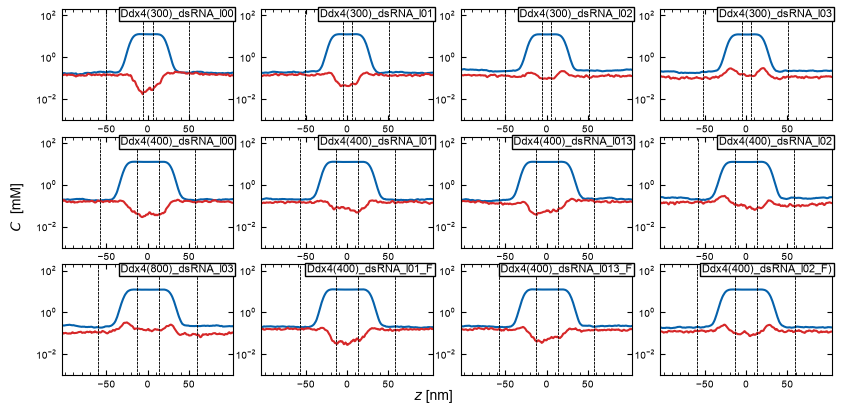

In [8]:
# density profules shown for each simulation

def ddx4_plot_density_profile(ax, name, comp_name, title, sdir="analysis/data/"):
    h = np.load(sdir+"hist_"+name+"_"+comp_name+'.npy')
    x = np.arange(0,len(h.mean(axis=0)))                   # bin size 1 nm
    x = x-np.mean(x)                                       # centering z=0
    
    # DDX4 in blue
    if comp_name is "DDX4":
        ax.plot(x, h.mean(axis=0), label="Ddx4", color=blue2)
    
    # RNA in red
    elif comp_name is "ds_acug24":
        ax.plot(x, h.mean(axis=0), label="dsRNA", color=cmap(3))
        
    # boundary line   
    bb = np.load(sdir+"cutoff_"+name+".npy")
    ax.vlines(bb,1e-3,2*1e2,color='black',linestyle="dashed",lw=0.5)
    
    # axis setting
    ax.set_ylim([1e-3, 2*1e2])
    ax.set_xlim([x[0], x[-1]])
    ax.set_yscale('log')
    
    ax.text(1, 1, title, ha='right', va='top', transform=ax.transAxes, fontsize=legend_fontsize, 
              bbox=dict(boxstyle="square,pad=0.15", facecolor="white", edgecolor="black", linewidth=1) )


#ax.legend(fontsize=8, loc='upper right',frameon=False) 
#ax.set_xlabel("$z$ [nm]",fontsize=8)
#ax.set_ylabel("$C$ [mM]",fontsize=8)
    


######################################################
# figure plot
fig,axs = plt.subplots(3,4,figsize=(8,4))
axs = axs.flat

legend_fontsize = 8


# DDX4 300 chains
name = "DDX4-300_ds_acug24-15_direct_l00"
ax = axs[0]
ddx4_plot_density_profile(ax, name, 'DDX4', "") 
ddx4_plot_density_profile(ax, name, 'ds_acug24', "Ddx4(300)_dsRNA_l00")

name = "DDX4-300_ds_acug24-15_direct_l01"
ax = axs[1]
ddx4_plot_density_profile(ax, name, 'DDX4', "") 
ddx4_plot_density_profile(ax, name, 'ds_acug24', "Ddx4(300)_dsRNA_l01")

name = "DDX4-300_ds_acug24-15_direct_l02"
ax = axs[2]
ddx4_plot_density_profile(ax, name, 'DDX4', "") 
ddx4_plot_density_profile(ax, name, 'ds_acug24', "Ddx4(300)_dsRNA_l02")

name = "DDX4-300_ds_acug24-15_direct_l03"
ax = axs[3]
ddx4_plot_density_profile(ax, name, 'DDX4', "") 
ddx4_plot_density_profile(ax, name, 'ds_acug24', "Ddx4(300)_dsRNA_l03")


# DDX4 400 chains
name = "DDX4-400_ds_acug24-15_direct_l00"
ax = axs[4]
ddx4_plot_density_profile(ax, name, 'DDX4', "") 
ddx4_plot_density_profile(ax, name, 'ds_acug24', "Ddx4(400)_dsRNA_l00")

name = "DDX4-400_ds_acug24-15_direct_l01"
ax = axs[5]
ddx4_plot_density_profile(ax, name, 'DDX4', "") 
ddx4_plot_density_profile(ax, name, 'ds_acug24', "Ddx4(400)_dsRNA_l01")

name = "DDX4-400_ds_acug24-15_direct_l013"
ax = axs[6]
ddx4_plot_density_profile(ax, name, 'DDX4', "") 
ddx4_plot_density_profile(ax, name, 'ds_acug24', "Ddx4(400)_dsRNA_l013")

name = "DDX4-400_ds_acug24-15_direct_l02"
ax = axs[7]
ddx4_plot_density_profile(ax, name, 'DDX4', "") 
ddx4_plot_density_profile(ax, name, 'ds_acug24', "Ddx4(400)_dsRNA_l02")

name = "DDX4-400_ds_acug24-15_direct_l03"
ax = axs[8]
ddx4_plot_density_profile(ax, name, 'DDX4', "") 
ddx4_plot_density_profile(ax, name, 'ds_acug24', "Ddx4(800)_dsRNA_l03")


# DDX4 400 chains flexibile

name = "DDX4-400_ds_acug24-15_direct_l01_k10"
ax = axs[9]
ddx4_plot_density_profile(ax, name, 'DDX4', "") 
ddx4_plot_density_profile(ax, name, 'ds_acug24', "Ddx4(400)_dsRNA_l01_F")

name = "DDX4-400_ds_acug24-15_direct_l013_k10"
ax = axs[10]
ddx4_plot_density_profile(ax, name, 'DDX4', "") 
ddx4_plot_density_profile(ax, name, 'ds_acug24', "Ddx4(400)_dsRNA_l013_F")

name = "DDX4-400_ds_acug24-15_direct_l02_k10"
ax = axs[11]
ddx4_plot_density_profile(ax, name, 'DDX4', "") 
ddx4_plot_density_profile(ax, name, 'ds_acug24', "Ddx4(400)_dsRNA_l02_F)")


fig.supxlabel("$z$ [nm]", fontsize=10)
fig.text(-0.03, 0.5, "$C$  [mM]", rotation=90, fontsize=10, va='center')
for ax in axs:
    ax.set_xticks(np.arange(-50,100,50)); ax.set_xticks(np.arange(-100,100,10),  minor=True)

# save figures
plt.tight_layout(pad=0.2)
plt.savefig("sup_densityprofile_ddx4dsrna.pdf", dpi=300, bbox_inches='tight')

plt.show()

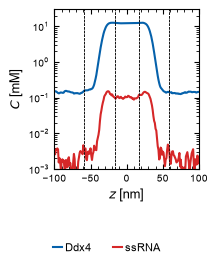

In [9]:
fig, ax = plt.subplots(1,1,figsize=(2.,2.7))

name = "DDX4-800_ss_acug24-8_1"
ddx4_plot_density_profile_ssRNA(ax, name, 'DDX4', "") 
ddx4_plot_density_profile_ssRNA(ax, name, 'ss_acug24', "")

ax.set_xlabel("$z$ [nm]",fontsize=9)
ax.set_ylabel("$C$ [mM]",fontsize=9)
ax.set_yscale('log')
ax.legend(
          bbox_to_anchor=(0.8,-0.4),
          frameon=False,
          edgecolor='k',
          handlelength=0.75,
          handletextpad=0.3,
          fontsize=8,ncol=2)  

ax.set_ylim([1e-3, 3*1e1])
ax.set_xticks(np.arange(-100,110,50)); ax.set_xticks(np.arange(-100,100,10),  minor=True)
plt.tight_layout(pad=0.1)

plt.savefig("ddx4_ssrna_density_profile.pdf",dpi=300)
plt.savefig("ddx4_ssrna_density_profile.svg",dpi=300)
plt.show()

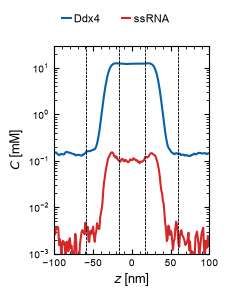

In [10]:
def pannel_plot_ddx4_ssrna_den_prof(ax):
    name = "DDX4-800_ss_acug24-8_1"
    ddx4_plot_density_profile_ssRNA(ax, name, 'DDX4', "") 
    ddx4_plot_density_profile_ssRNA(ax, name, 'ss_acug24', "")
    
    ax.set_xlabel("$z$ [nm]",fontsize=9)
    ax.set_ylabel("$C$ [mM]",fontsize=9)
    ax.set_yscale('log')
    ax.legend(
              bbox_to_anchor=(0.394, 1.2),
              frameon=False,
              edgecolor='k',
              handlelength=0.75,
              handletextpad=0.3,
              fontsize=8,ncol=2, loc="upper center")  
    
    ax.set_ylim([1e-3, 3*1e1])
    ax.set_xticks(np.arange(-100,110,50)); ax.set_xticks(np.arange(-100,100,10),  minor=True)

fig, ax = plt.subplots(1,1,figsize=(2.,2.7))
pannel_plot_ddx4_ssrna_den_prof(ax) 
plt.show()

In [11]:
## phase diagram
# load phase diagram 
# produce dilute and dense phase plots 


def error_prop(x,y,ex,ey):
    """
    this function has two steps
    1. Error of x/y is computed by error perturbation  
    2. Error of log(y) is computed by error pertubation
    """ 
    # Error of x/y
    err_1 = np.sqrt( (1/y*ex)**2 + (x/y/y*ey)**2 )
    
    # Error of ln y
    err_2 = err_1/(x/y)
    return err_2


def load_phase_diagram_data(name, ddx4_exp = 162.5, rna_name = 'ss_acug24'):
    path = './analysis/data/'
    name = "conc_" + name

    # load RNA concentration of the dilute and dense phases
    rna_conc = np.load(path+name+"_{:s}.npy".format(rna_name))
    rna_dens_mean = rna_conc[2]*1e3
    rna_dens_std = rna_conc[3]*1e3
    rna_dil_mean = rna_conc[0]*1e3
    rna_dil_std = rna_conc[1]*1e3

    # load DDX4 concentration 
    pro_conc = np.load(path+name+"_DDX4.npy")
    pro_dens_mean = pro_conc[2]*1e3
    pro_dens_std = pro_conc[3]*1e3
    pro_dil_mean = pro_conc[0]*1e3
    pro_dil_std = pro_conc[1]*1e3

    # tie-line interpolation
    a = (rna_dens_mean-rna_dil_mean)/(pro_dens_mean-pro_dil_mean)
    rna_conc_at_ddx4_exp = a*(ddx4_exp-pro_dil_mean) + rna_dil_mean
    
    # compute partitioning free energy
    RT = 8.31*1e-3 * 293
    dG = -np.log(rna_dens_mean/rna_dil_mean) * RT 
    dG_err = error_prop(rna_dens_mean,rna_dil_mean,rna_dens_std,rna_dil_std) * RT
 
    protein_concentrations = [pro_dil_mean, pro_dil_std, pro_dens_mean, pro_dens_std]  
    rna_concentrations =  [rna_dil_mean, rna_dil_std, rna_dens_mean, rna_dens_std]  
    rna_dG = [dG, dG_err]
    
    print(name)
    print("Pro", protein_concentrations)
    print("RNA", rna_concentrations)
    print("RNA dG", rna_dG)
    print("interpolated RNA conc", rna_conc_at_ddx4_exp)
    print("=="*20)
    
    return protein_concentrations, rna_concentrations, rna_dG, rna_conc_at_ddx4_exp  


def format_with_error(mean, std, decimal_places=2):
    """Format value as 'mean ± std'"""
    fmt = f"{{:.{decimal_places}f}}"
    return f"{fmt.format(mean)} ± {fmt.format(std)}"


# settings for table 
rows = []
decimal_places = 2

# 400 chain
names = ["DDX4-400_ss_acug24-8", 
         "DDX4-400_ss_acug24-16",
         "DDX4-400_ss_acug24-24",
         "DDX4-400_ss_acug24-32"]
for name in names:
    pro_conc, rna_conc, dG, rna_at_ddx4 = load_phase_diagram_data(name, ddx4_exp = 162.5)

    row = {
        'Name': name,
        'Pro dilute (μM)': format_with_error(pro_conc[0], pro_conc[1], decimal_places),
        'Pro dense (μM)': format_with_error(pro_conc[2], pro_conc[3], decimal_places),
        'RNA dilute (μM)': format_with_error(rna_conc[0], rna_conc[1], decimal_places),
        'RNA dense (μM)': format_with_error(rna_conc[2], rna_conc[3], decimal_places),
        'ΔG (kJ/mol)': format_with_error(dG[0], dG[1], decimal_places),
    }
    rows.append(row)

#  800 chain, ssRNA 16 chain
pro_dil_800_16 = []
pro_den_800_16 = []
rna_dil_800_16 = []
rna_den_800_16 = []
dG_800_16 = []
rna_interpolate_800_16 = [] 
for run_id in ["_1","_2","_3","_4","_5"]:
    a0, a1, a2, a3 = load_phase_diagram_data("DDX4-800_ss_acug24-16"+run_id, ddx4_exp = 162.5)
    pro_dil_800_16.append(a0[0])
    pro_den_800_16.append(a0[2])
    rna_dil_800_16.append(a1[0])
    rna_den_800_16.append(a1[2])
    dG_800_16.append(a2[0])
    rna_interpolate_800_16.append(a3)

n_runs = 5
row = {
    'Name': "DDX4-800_ss_acug24-16",
    'Pro dilute (μM)': format_with_error(np.mean(pro_dil_800_16), np.std(pro_dil_800_16)/np.sqrt(n_runs), decimal_places),
    'Pro dense (μM)': format_with_error(np.mean(pro_den_800_16),  np.std(pro_den_800_16)/np.sqrt(n_runs), decimal_places),
    'RNA dilute (μM)': format_with_error(np.mean(rna_dil_800_16), np.std(rna_dil_800_16)/np.sqrt(n_runs), decimal_places),
    'RNA dense (μM)': format_with_error(np.mean(rna_den_800_16),  np.std(rna_den_800_16)/np.sqrt(n_runs), decimal_places),
    'ΔG (kJ/mol)': format_with_error(np.mean(dG_800_16),          np.std(dG_800_16)/np.sqrt(n_runs),      decimal_places),
}
rows.append(row)

#  800 chain, ssRNA 8 chain
pro_dil_800_8 = []
pro_den_800_8 = []
rna_dil_800_8 = []
rna_den_800_8 = []
dG_800_8 = []
rna_interpolate_800_8 = [] 
for run_id in ["_1","_2","_3","_4"]:
    a0, a1, a2, a3 = load_phase_diagram_data("DDX4-800_ss_acug24-8"+run_id, ddx4_exp = 162.5)
    pro_dil_800_8.append(a0[0])
    pro_den_800_8.append(a0[2])
    rna_dil_800_8.append(a1[0])
    rna_den_800_8.append(a1[2])
    dG_800_8.append(a2[0])
    rna_interpolate_800_8.append(a3)

n_runs = 4
row = {
    'Name': "DDX4-800_ss_acug24-8",
    'Pro dilute (μM)': format_with_error(np.mean(pro_dil_800_8), np.std(pro_dil_800_8)/np.sqrt(n_runs), decimal_places),
    'Pro dense (μM)': format_with_error(np.mean(pro_den_800_8),  np.std(pro_den_800_8)/np.sqrt(n_runs), decimal_places),
    'RNA dilute (μM)': format_with_error(np.mean(rna_dil_800_8), np.std(rna_dil_800_8)/np.sqrt(n_runs), decimal_places),
    'RNA dense (μM)': format_with_error(np.mean(rna_den_800_8),  np.std(rna_den_800_8)/np.sqrt(n_runs), decimal_places),
    'ΔG (kJ/mol)': format_with_error(np.mean(dG_800_8),          np.std(dG_800_8)/np.sqrt(n_runs),      decimal_places),
}
rows.append(row)


# show table
df = pd.DataFrame(rows)
display(df)

conc_DDX4-400_ss_acug24-8
Pro [np.float64(130.98466996673568), np.float64(8.587076181723294), np.float64(12232.41884135275), np.float64(30.85248049971529)]
RNA [np.float64(3.7169432978549546), np.float64(0.8315892100350775), np.float64(219.70391206802142), np.float64(8.72292271306788)]
RNA dG [np.float64(-9.932594733984176), np.float64(0.5532539491342279)]
interpolated RNA conc 4.279430397092428
conc_DDX4-400_ss_acug24-16
Pro [np.float64(182.37154211421404), np.float64(15.910304224287179), np.float64(12042.298950487442), np.float64(41.920529750437254)]
RNA [np.float64(11.887314845313156), np.float64(2.0972748581799676), np.float64(389.3901373974439), np.float64(10.537054690030883)]
RNA dG [np.float64(-8.495389488873851), np.float64(0.43459968592337184)]
interpolated RNA conc 11.25480142610933
conc_DDX4-400_ss_acug24-24
Pro [np.float64(160.0628338699854), np.float64(12.324105253318917), np.float64(11845.641427249604), np.float64(52.35289917091754)]
RNA [np.float64(21.41060952617652), np

,Name,Pro dilute (μM),Pro dense (μM),RNA dilute (μM),RNA dense (μM),ΔG (kJ/mol)
0,DDX4-400_ss_acug24-8,130.98 ± 8.59,12232.42 ± 30.85,3.72 ± 0.83,219.70 ± 8.72,-9.93 ± 0.55
1,DDX4-400_ss_acug24-16,182.37 ± 15.91,12042.30 ± 41.92,11.89 ± 2.10,389.39 ± 10.54,-8.50 ± 0.43
2,DDX4-400_ss_acug24-24,160.06 ± 12.32,11845.64 ± 52.35,21.41 ± 2.10,582.50 ± 13.85,-8.04 ± 0.25
3,DDX4-400_ss_acug24-32,182.22 ± 14.59,11576.70 ± 56.02,37.27 ± 4.18,777.05 ± 16.21,-7.40 ± 0.28
4,DDX4-800_ss_acug24-16,151.41 ± 7.47,12318.87 ± 20.76,4.31 ± 0.39,196.35 ± 1.66,-9.36 ± 0.25
5,DDX4-800_ss_acug24-8,153.01 ± 4.10,12336.48 ± 7.31,2.61 ± 0.42,104.18 ± 1.75,-9.09 ± 0.36


conc_DDX4-400_ss_acug24-16
Pro [np.float64(182.37154211421404), np.float64(15.910304224287179), np.float64(12042.298950487442), np.float64(41.920529750437254)]
RNA [np.float64(11.887314845313156), np.float64(2.0972748581799676), np.float64(389.3901373974439), np.float64(10.537054690030883)]
RNA dG [np.float64(-8.495389488873851), np.float64(0.43459968592337184)]
interpolated RNA conc 11.25480142610933
conc_DDX4-400_ss_acug24-24
Pro [np.float64(160.0628338699854), np.float64(12.324105253318917), np.float64(11845.641427249604), np.float64(52.35289917091754)]
RNA [np.float64(21.41060952617652), np.float64(2.0977951333800116), np.float64(582.5049236475857), np.float64(13.846925438614326)]
RNA dG [np.float64(-8.043341760473677), np.float64(0.24548360389727253)]
interpolated RNA conc 21.527632405890426
conc_DDX4-400_ss_acug24-32
Pro [np.float64(182.2192285493514), np.float64(14.5860740247679), np.float64(11576.69717209737), np.float64(56.01700721364756)]
RNA [np.float64(37.2669872697549), np

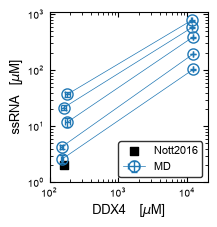

In [12]:
def plot_phase_digagram(name,marker="o",color='k'):
    
    # a0 = protein_concentrations
    # a1 = rna_concentrations
    # a3 = rna_dG
    # a4 = rna_conc_at_ddx4_exp
    
    a0, a1, a2, a3 = load_phase_diagram_data(name, ddx4_exp = 162.5)

    ax.errorbar([a0[0], a0[2]],
                [a1[0], a1[2]],
                xerr=[a0[1], a0[3]], 
                yerr=[a1[1], a1[3]],  
                lw=0.5, marker=marker, ms=8, elinewidth=1, capsize=2, capthick=1,
                markerfacecolor='none', color=color) 

            
fig,ax = plt.subplots(1,1,figsize=(2,2.1))

# 400 chains
#plot_phase_digagram("DDX4-400_ss_acug24-8",marker="o",color='k')
plot_phase_digagram("DDX4-400_ss_acug24-16",marker="o",color=cmap(0))
plot_phase_digagram("DDX4-400_ss_acug24-24",marker="o",color=cmap(0))
plot_phase_digagram("DDX4-400_ss_acug24-32",marker="o",color=cmap(0))

# 800 chains, ssRNA 16 chains
n_runs = 5
b0 = [np.mean(pro_dil_800_16), np.std(pro_dil_800_16)/np.sqrt(n_runs), np.mean(pro_den_800_16), np.std(pro_den_800_16)/np.sqrt(n_runs)]
b1 = [np.mean(rna_dil_800_16), np.std(rna_dil_800_16)/np.sqrt(n_runs), np.mean(rna_den_800_16), np.std(rna_den_800_16)/np.sqrt(n_runs)]
b2 = [np.mean(dG_800_16),      np.std(dG_800_16)/np.sqrt(n_runs)]
b3 = [np.mean(rna_interpolate_800_16),      np.std(rna_interpolate_800_16)/np.sqrt(n_runs)]

ax.errorbar([b0[0], b0[2]],
            [b1[0], b1[2]],
            xerr=[b0[1], b0[3]], 
            yerr=[b1[1], b1[3]],  
            lw=0.5, marker='o', ms=8, elinewidth=1, capsize=2, capthick=1,
            markerfacecolor='none', color=cmap(0)) 

# 800 chains, ssRNA 8 chains
n_runs = 4
c0 = [np.mean(pro_dil_800_8), np.std(pro_dil_800_8)/np.sqrt(n_runs), np.mean(pro_den_800_8), np.std(pro_den_800_8)/np.sqrt(n_runs)]
c1 = [np.mean(rna_dil_800_8), np.std(rna_dil_800_8)/np.sqrt(n_runs), np.mean(rna_den_800_8), np.std(rna_den_800_8)/np.sqrt(n_runs)]
c2 = [np.mean(dG_800_8),      np.std(dG_800_8)/np.sqrt(n_runs)]
c3 = [np.mean(rna_interpolate_800_8),      np.std(rna_interpolate_800_8)/np.sqrt(n_runs)]
print("800 chains, ssRNA 8 chains")
print("interpolated ssRNA", np.mean(rna_interpolate_800_8), "±", np.std(rna_interpolate_800_8)/np.sqrt(n_runs), "uM")
ax.errorbar([c0[0], c0[2]],
            [c1[0], c1[2]],
            xerr=[c0[1], c0[3]], 
            yerr=[c1[1], c1[3]],  
            lw=0.5, marker='o', ms=8, elinewidth=1, capsize=2, capthick=1,
            markerfacecolor='none', color=cmap(0), label='MD') 


# Experimental conditions Nott 2016
ddx4_exp = 162.5 # Experiment data from Nott 2016
rna_exp = 2 # Experiment data from Nott 2016
ax.scatter(ddx4_exp, rna_exp, label="Nott2016", marker="s", color='k', s=40)


ax.set_xlabel("DDX4    [$\mu$M]",fontsize=9)
ax.set_ylabel("ssRNA   [$\mu$M]",fontsize=9)
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(loc='lower right',edgecolor='k',fontsize=8)  
ax.set_xlim([1e2, 2.*1e4])
ax.set_ylim([1e0, 1.1*1e3])

plt.tight_layout(pad=0.1)
plt.savefig("ddx4_ssrna_phase-diagram.pdf",dpi=300)
plt.savefig("ddx4_ssrna_phase-diagram.svg",dpi=300)
plt.show()

conc_DDX4-400_ss_acug24-16
Pro [np.float64(182.37154211421404), np.float64(15.910304224287179), np.float64(12042.298950487442), np.float64(41.920529750437254)]
RNA [np.float64(11.887314845313156), np.float64(2.0972748581799676), np.float64(389.3901373974439), np.float64(10.537054690030883)]
RNA dG [np.float64(-8.495389488873851), np.float64(0.43459968592337184)]
interpolated RNA conc 11.25480142610933
conc_DDX4-400_ss_acug24-24
Pro [np.float64(160.0628338699854), np.float64(12.324105253318917), np.float64(11845.641427249604), np.float64(52.35289917091754)]
RNA [np.float64(21.41060952617652), np.float64(2.0977951333800116), np.float64(582.5049236475857), np.float64(13.846925438614326)]
RNA dG [np.float64(-8.043341760473677), np.float64(0.24548360389727253)]
interpolated RNA conc 21.527632405890426
conc_DDX4-400_ss_acug24-32
Pro [np.float64(182.2192285493514), np.float64(14.5860740247679), np.float64(11576.69717209737), np.float64(56.01700721364756)]
RNA [np.float64(37.2669872697549), np

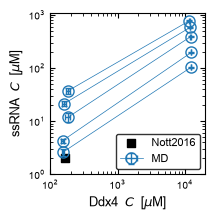

In [13]:
def plot_phase_digagram(ax, name,marker="o",color='k'):
    
    # a0 = protein_concentrations
    # a1 = rna_concentrations
    # a3 = rna_dG
    # a4 = rna_conc_at_ddx4_exp
    
    a0, a1, a2, a3 = load_phase_diagram_data(name, ddx4_exp = 162.5)

    ax.errorbar([a0[0], a0[2]],
                [a1[0], a1[2]],
                xerr=[a0[1], a0[3]], 
                yerr=[a1[1], a1[3]],  
                lw=0.5, marker=marker, ms=8, elinewidth=1, capsize=2, capthick=1,
                markerfacecolor='none', color=color) 
    
def pannel_plot_phase_diag(ax):
    # 400 chains
    #plot_phase_digagram("DDX4-400_ss_acug24-8",marker="o",color='k')
    plot_phase_digagram(ax, "DDX4-400_ss_acug24-16",marker="o",color=cmap(0))
    plot_phase_digagram(ax, "DDX4-400_ss_acug24-24",marker="o",color=cmap(0))
    plot_phase_digagram(ax, "DDX4-400_ss_acug24-32",marker="o",color=cmap(0))

    # 800 chains, ssRNA 16 chains
    n_runs = 5
    b0 = [np.mean(pro_dil_800_16), np.std(pro_dil_800_16)/np.sqrt(n_runs), np.mean(pro_den_800_16), np.std(pro_den_800_16)/np.sqrt(n_runs)]
    b1 = [np.mean(rna_dil_800_16), np.std(rna_dil_800_16)/np.sqrt(n_runs), np.mean(rna_den_800_16), np.std(rna_den_800_16)/np.sqrt(n_runs)]
    b2 = [np.mean(dG_800_16),      np.std(dG_800_16)/np.sqrt(n_runs)]
    b3 = [np.mean(rna_interpolate_800_16),      np.std(rna_interpolate_800_16)/np.sqrt(n_runs)]

    ax.errorbar([b0[0], b0[2]],
                [b1[0], b1[2]],
                xerr=[b0[1], b0[3]], 
                yerr=[b1[1], b1[3]],  
                lw=0.5, marker='o', ms=8, elinewidth=1, capsize=2, capthick=1,
                markerfacecolor='none', color=cmap(0)) 

    # 800 chains, ssRNA 8 chains
    n_runs = 4
    c0 = [np.mean(pro_dil_800_8), np.std(pro_dil_800_8)/np.sqrt(n_runs), np.mean(pro_den_800_8), np.std(pro_den_800_8)/np.sqrt(n_runs)]
    c1 = [np.mean(rna_dil_800_8), np.std(rna_dil_800_8)/np.sqrt(n_runs), np.mean(rna_den_800_8), np.std(rna_den_800_8)/np.sqrt(n_runs)]
    c2 = [np.mean(dG_800_8),      np.std(dG_800_8)/np.sqrt(n_runs)]
    c3 = [np.mean(rna_interpolate_800_8),      np.std(rna_interpolate_800_8)/np.sqrt(n_runs)]
    print("800 chains, ssRNA 8 chains")
    print("interpolated ssRNA", np.mean(rna_interpolate_800_8), "±", np.std(rna_interpolate_800_8)/np.sqrt(n_runs), "uM")
    ax.errorbar([c0[0], c0[2]],
                [c1[0], c1[2]],
                xerr=[c0[1], c0[3]], 
                yerr=[c1[1], c1[3]],  
                lw=0.5, marker='o', ms=8, elinewidth=1, capsize=2, capthick=1,
                markerfacecolor='none', color=cmap(0), label='MD') 
    
    
    # Experimental conditions Nott 2016
    ddx4_exp = 162.5 # Experiment data from Nott 2016
    rna_exp = 2 # Experiment data from Nott 2016
    ax.scatter(ddx4_exp, rna_exp, label="Nott2016", marker="s", color='k', s=40)
    
    
    ax.set_xlabel("Ddx4  $C$  [$\mu$M]",fontsize=9)
    ax.set_ylabel("ssRNA  $C$  [$\mu$M]",fontsize=9)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend(loc='lower right',edgecolor='k',fontsize=8)  
    ax.set_xlim([1e2, 2.*1e4])
    ax.set_ylim([1e0, 1.1*1e3])


fig,ax = plt.subplots(1,1,figsize=(2,2.1))
pannel_plot_phase_diag(ax)
plt.show()

conc_DDX4-400_ss_acug24-16
Pro [np.float64(182.37154211421404), np.float64(15.910304224287179), np.float64(12042.298950487442), np.float64(41.920529750437254)]
RNA [np.float64(11.887314845313156), np.float64(2.0972748581799676), np.float64(389.3901373974439), np.float64(10.537054690030883)]
RNA dG [np.float64(-8.495389488873851), np.float64(0.43459968592337184)]
interpolated RNA conc 11.25480142610933
conc_DDX4-400_ss_acug24-24
Pro [np.float64(160.0628338699854), np.float64(12.324105253318917), np.float64(11845.641427249604), np.float64(52.35289917091754)]
RNA [np.float64(21.41060952617652), np.float64(2.0977951333800116), np.float64(582.5049236475857), np.float64(13.846925438614326)]
RNA dG [np.float64(-8.043341760473677), np.float64(0.24548360389727253)]
interpolated RNA conc 21.527632405890426
conc_DDX4-400_ss_acug24-32
Pro [np.float64(182.2192285493514), np.float64(14.5860740247679), np.float64(11576.69717209737), np.float64(56.01700721364756)]
RNA [np.float64(37.2669872697549), np

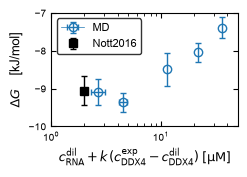

In [14]:
fig,ax = plt.subplots(1,1,figsize=(2.3,1.6))

def plot_dG(ax,name,marker="o",color='k'):
    
    # a0 = protein_concentrations
    # a1 = rna_concentrations
    # a3 = rna_dG
    # a4 = rna_conc_at_ddx4_exp
    
    a0, a1, a2, a3 = load_phase_diagram_data(name, ddx4_exp = 162.5)

    ax.errorbar(a3, a2[0], yerr=a2[1],  
                lw=0.5, marker=marker, ms=6, elinewidth=1, capsize=2, capthick=1,
                markerfacecolor='none', color=color) 

# 400 chains    
plot_dG(ax, "DDX4-400_ss_acug24-16",marker="o",color=cmap(0))
plot_dG(ax, "DDX4-400_ss_acug24-24",marker="o",color=cmap(0))
plot_dG(ax, "DDX4-400_ss_acug24-32",marker="o",color=cmap(0))


# 800 chains, 16 ssRNA
ax.errorbar(b3[0], b2[0], xerr=b3[1], yerr=b2[1],
            lw=0.5, marker='o', ms=6, elinewidth=1, capsize=2, capthick=1,
            markerfacecolor='none', color=cmap(0)) 

# 800 chains, 8 ssRNA
ax.errorbar(c3[0], c2[0], xerr=c3[1], yerr=c2[1],
            lw=0.5, marker='o', ms=6, elinewidth=1, capsize=2, capthick=1,
            markerfacecolor='none', color=cmap(0), label='MD') 


# Nott 2016
ddx4_exp = 162.5
rna_exp = 2
dG_exp = -9.06
dG_err_exp = 0.38
ax.errorbar(rna_exp, dG_exp, yerr=dG_err_exp,
            label="Nott2016",color='k', marker="s",
                lw=0, ms=6, elinewidth=1, capsize=2, capthick=1) 


ax.set_xscale('log')
ax.set_xlabel(
    r"$c_{\mathrm{RNA}}^{\mathrm{dil}}"
    r"+k\,(c_{\mathrm{DDX4}}^{\mathrm{exp}}-c_{\mathrm{DDX4}}^{\mathrm{dil}})"
    r"\;[\mathrm{\mu M}]$",
    fontsize=9
)                #ax.set_xlabel("RNA conc [uM] @ DDX4 {:s} [uM]".format( str(ddx4_exp)[:5]))
ax.set_ylabel('$\Delta G$    [kJ/mol]', fontsize=9) #ddx4_exp = 162.5
ax.legend(edgecolor='k', fontsize=8, loc='upper left')  
ax.set_ylim([-10,-7])
ax.set_xlim([1e0, 5*1e1])

plt.tight_layout(pad=0.1)
plt.savefig("ddx4_ssrna_deltaG_rna_conc.pdf",dpi=300)
plt.savefig("ddx4_ssrna_deltaG_rna_conc.svg",dpi=300)
plt.show()

conc_DDX4-400_ss_acug24-16
Pro [np.float64(182.37154211421404), np.float64(15.910304224287179), np.float64(12042.298950487442), np.float64(41.920529750437254)]
RNA [np.float64(11.887314845313156), np.float64(2.0972748581799676), np.float64(389.3901373974439), np.float64(10.537054690030883)]
RNA dG [np.float64(-8.495389488873851), np.float64(0.43459968592337184)]
interpolated RNA conc 11.25480142610933
conc_DDX4-400_ss_acug24-24
Pro [np.float64(160.0628338699854), np.float64(12.324105253318917), np.float64(11845.641427249604), np.float64(52.35289917091754)]
RNA [np.float64(21.41060952617652), np.float64(2.0977951333800116), np.float64(582.5049236475857), np.float64(13.846925438614326)]
RNA dG [np.float64(-8.043341760473677), np.float64(0.24548360389727253)]
interpolated RNA conc 21.527632405890426
conc_DDX4-400_ss_acug24-32
Pro [np.float64(182.2192285493514), np.float64(14.5860740247679), np.float64(11576.69717209737), np.float64(56.01700721364756)]
RNA [np.float64(37.2669872697549), np

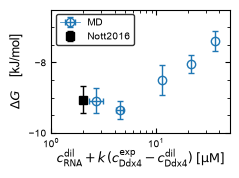

In [15]:
def plot_dG(ax,name,marker="o",color='k'):
    
    # a0 = protein_concentrations
    # a1 = rna_concentrations
    # a3 = rna_dG
    # a4 = rna_conc_at_ddx4_exp
    
    a0, a1, a2, a3 = load_phase_diagram_data(name, ddx4_exp = 162.5)

    ax.errorbar(a3, a2[0], yerr=a2[1],  
                lw=0.5, marker=marker, ms=6, elinewidth=1, capsize=2, capthick=1,
                markerfacecolor='none', color=color) 


def pannel_plot_rna_dg(ax):
    # 400 chains    
    plot_dG(ax, "DDX4-400_ss_acug24-16",marker="o",color=cmap(0))
    plot_dG(ax, "DDX4-400_ss_acug24-24",marker="o",color=cmap(0))
    plot_dG(ax, "DDX4-400_ss_acug24-32",marker="o",color=cmap(0))
    
    
    # 800 chains, 16 ssRNA
    ax.errorbar(b3[0], b2[0], xerr=b3[1], yerr=b2[1],
                lw=0.5, marker='o', ms=6, elinewidth=1, capsize=2, capthick=1,
                markerfacecolor='none', color=cmap(0)) 
    
    # 800 chains, 8 ssRNA
    ax.errorbar(c3[0], c2[0], xerr=c3[1], yerr=c2[1],
                lw=0.5, marker='o', ms=6, elinewidth=1, capsize=2, capthick=1,
                markerfacecolor='none', color=cmap(0), label='MD') 
    
    
    # Nott 2016
    ddx4_exp = 162.5
    rna_exp = 2
    dG_exp = -9.06
    dG_err_exp = 0.38
    ax.errorbar(rna_exp, dG_exp, yerr=dG_err_exp,
                label="Nott2016",color='k', marker="s",
                    lw=0, ms=6, elinewidth=1, capsize=2, capthick=1) 
    
    
    ax.set_xscale('log')
    ax.set_xlabel(
        r"$c_{\mathrm{RNA}}^{\mathrm{dil}}"
        r"+k\,(c_{\mathrm{Ddx4}}^{\mathrm{exp}}-c_{\mathrm{Ddx4}}^{\mathrm{dil}})"
        r"\;[\mathrm{\mu M}]$",
        fontsize=9,
        labelpad=0.1
    )                #ax.set_xlabel("RNA conc [uM] @ DDX4 {:s} [uM]".format( str(ddx4_exp)[:5]))
    ax.set_ylabel('$\Delta G$    [kJ/mol]', fontsize=9) #ddx4_exp = 162.5
    ax.legend(edgecolor='k', fontsize=7, loc='upper left')  
    ax.set_ylim([-10,-6.5])
    ax.set_xlim([1e0, 5*1e1])
    ax.set_yticks(np.arange(-10, -6.9, 2))
    ax.set_yticks(np.arange(-10, -6.9, 0.5),  minor=True)



fig, ax = plt.subplots(1,1,figsize=(2.3,1.6))
pannel_plot_rna_dg(ax)
plt.show()

In [16]:
import matplotlib.image as mpimg
def pannel_ddx4_ssrna(ax):
    img = mpimg.imread("./figdata/ddx4_ssrna_slab.png")
    ax.imshow(img)
    ax.axis("off")

def pannel_tieline(ax):
    img = mpimg.imread("./figdata/tieline.png")
    ax.imshow(img)
    ax.axis("off")

conc_DDX4-400_ss_acug24-16
Pro [np.float64(182.37154211421404), np.float64(15.910304224287179), np.float64(12042.298950487442), np.float64(41.920529750437254)]
RNA [np.float64(11.887314845313156), np.float64(2.0972748581799676), np.float64(389.3901373974439), np.float64(10.537054690030883)]
RNA dG [np.float64(-8.495389488873851), np.float64(0.43459968592337184)]
interpolated RNA conc 11.25480142610933
conc_DDX4-400_ss_acug24-24
Pro [np.float64(160.0628338699854), np.float64(12.324105253318917), np.float64(11845.641427249604), np.float64(52.35289917091754)]
RNA [np.float64(21.41060952617652), np.float64(2.0977951333800116), np.float64(582.5049236475857), np.float64(13.846925438614326)]
RNA dG [np.float64(-8.043341760473677), np.float64(0.24548360389727253)]
interpolated RNA conc 21.527632405890426
conc_DDX4-400_ss_acug24-32
Pro [np.float64(182.2192285493514), np.float64(14.5860740247679), np.float64(11576.69717209737), np.float64(56.01700721364756)]
RNA [np.float64(37.2669872697549), np

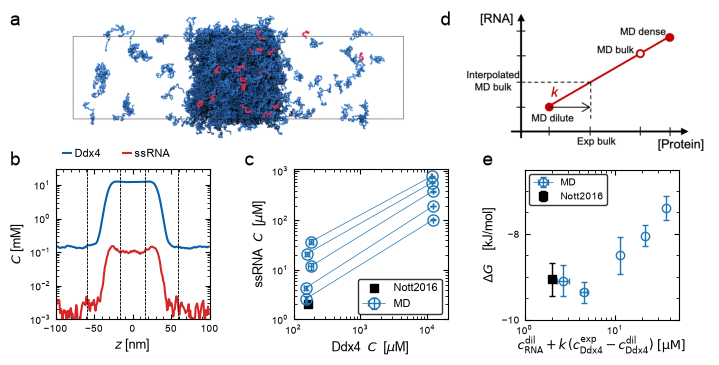

In [17]:
import matplotlib.image as mpimg

fig = plt.figure(figsize=(7, 3.5))

ax1 = fig.add_axes([-0.0, 0.62, 0.66, 0.66*452/782])
pannel_ddx4_ssrna(ax1)

ax2 = fig.add_axes([0.07, 0.12, 0.22, 0.43])
pannel_plot_ddx4_ssrna_den_prof(ax2)

ax3 = fig.add_axes([0.41, 0.12, 0.22, 0.43])
pannel_plot_phase_diag(ax3)

ax4 = fig.add_axes([0.655, 0.50, 0.35, 0.35*782/452])
pannel_tieline(ax4)

ax5 = fig.add_axes([0.74, 0.119, 0.22, 0.429])
pannel_plot_rna_dg(ax5)


fig.text(0.005, 0.96, "a", fontsize=14)
fig.text(0.005, 0.56, "b", fontsize=14)
fig.text(0.34, 0.56, "c", fontsize=14)
fig.text(0.62, 0.96, "d", fontsize=14)
fig.text(0.68, 0.56, "e", fontsize=14)


plt.savefig("./figure1.pdf", dpi=300)
plt.show()

# dsRNA and DDX4

-104.0 104.0
-104.0 104.0
-104.0 104.0
-104.0 104.0


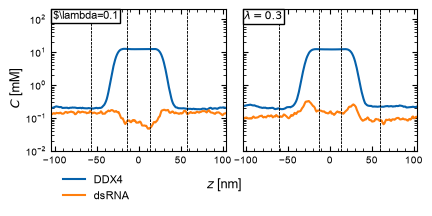

In [18]:
# density profules shown for each simulation

def ddx4_plot_density_profile(ax, name, comp_name, title, sdir="analysis/data/"):
    h = np.load(sdir+"hist_"+name+"_"+comp_name+'.npy')
    x = np.arange(0,len(h.mean(axis=0)))                   # bin size 1 nm
    x = x-np.mean(x)                                       # centering z=0
    
    # DDX4 in blue
    if comp_name is "DDX4":
        ax.plot(x, h.mean(axis=0), label="DDX4", color=blue2)
    
    # RNA in red
    elif comp_name is "ds_acug24":
        ax.plot(x, h.mean(axis=0), label="dsRNA", color=cmap(1))
        
    # boundary line   
    bb = np.load(sdir+"cutoff_"+name+".npy")
    ax.vlines(bb,1e-3,2*1e2,color='black',linestyle="dashed",lw=0.5)
    
    # axis setting
    ax.set_ylim([1e-2, 2*1e2])
    ax.set_xlim([x[0], x[-1]])
    ax.set_yscale('log')
    print(x[0], x[-1])
    ax.text(0.01, 0.99, title, ha='left', va='top', transform=ax.transAxes, fontsize=legend_fontsize, 
              bbox=dict(boxstyle="square,pad=0.15", facecolor="white", edgecolor="black", linewidth=1) )


######################################################
# figure plot
fig,axs = plt.subplots(1,2,figsize=(4,2), sharey=True)
axs = axs.flat

legend_fontsize = 8

name = "DDX4-400_ds_acug24-15_direct_l01"
ax = axs[0]
ddx4_plot_density_profile(ax, name, 'DDX4', "") 
ddx4_plot_density_profile(ax, name, 'ds_acug24', "$\lambda=0.1")
ax.legend(fontsize=8, 
          edgecolor='k', 
          bbox_to_anchor=(0.5, -0.1),
          frameon=False,
          ncol=1)

ax.set_xticks(np.arange(-100,104,50)); ax.set_xticks(np.arange(-100,104,10),minor=True)


name = "DDX4-400_ds_acug24-15_direct_l03"
ax = axs[1]
ddx4_plot_density_profile(ax, name, 'DDX4', "") 
ddx4_plot_density_profile(ax, name, 'ds_acug24', "$\lambda=0.3$")

ax.set_xticks(np.arange(-100,104,50)); ax.set_xticks(np.arange(-100,104,10),minor=True)

fig.text(0.5, 0.1, r'$z$ [nm]', ha='center', fontsize=9)
fig.text(0.-0.02, 0.6, r'$C$ [mM]', ha='center',
         va='center', rotation='vertical', fontsize=9)

# save figures
plt.tight_layout(pad=0.1)
plt.savefig("ddx4_dsrna_density_profile.svg",dpi=300)
plt.show()

-104.0 104.0
-104.0 104.0
-104.0 104.0
-104.0 104.0


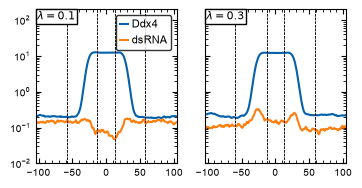

In [19]:
# density profules shown for each simulation

def ddx4_plot_density_profile(ax, name, comp_name, title, sdir="analysis/data/"):
    h = np.load(sdir+"hist_"+name+"_"+comp_name+'.npy')
    x = np.arange(0,len(h.mean(axis=0)))                   # bin size 1 nm
    x = x-np.mean(x)                                       # centering z=0
    
    # DDX4 in blue
    if comp_name is "DDX4":
        ax.plot(x, h.mean(axis=0), label="Ddx4", color=blue2)
    
    # RNA in red
    elif comp_name is "ds_acug24":
        ax.plot(x, h.mean(axis=0), label="dsRNA", color=cmap(1))
        
    # boundary line   
    bb = np.load(sdir+"cutoff_"+name+".npy")
    ax.vlines(bb,1e-3,2*1e2,color='black',linestyle="dashed",lw=0.5)
    
    # axis setting
    ax.set_ylim([1e-2, 2*1e2])
    ax.set_xlim([x[0], x[-1]])
    ax.set_yscale('log')
    print(x[0], x[-1])
    ax.text(0.01, 0.99, title, ha='left', va='top', transform=ax.transAxes, fontsize=legend_fontsize, 
              bbox=dict(boxstyle="square,pad=0.15", facecolor="white", edgecolor="black", linewidth=1) )


def pannel_ddx4_dsrna_dens_prof(axs):

    legend_fontsize = 7
    ax = axs[0]
    name = "DDX4-400_ds_acug24-15_direct_l01"
    ddx4_plot_density_profile(ax, name, 'DDX4', "") 
    ddx4_plot_density_profile(ax, name, 'ds_acug24', "$\lambda=0.1$")
    ax.legend(fontsize=8, 
              edgecolor='k', 
              #bbox_to_anchor=(0.2, -0.5),
              frameon=True,
              handlelength=0.75,
              handletextpad=0.3,              
              ncol=1, loc="upper right")
    
    ax.set_xticks(np.arange(-100,104,50)); ax.set_xticks(np.arange(-100,104,10),minor=True)
    
    ax = axs[1]
    name = "DDX4-400_ds_acug24-15_direct_l03"
    ddx4_plot_density_profile(ax, name, 'DDX4', "") 
    ddx4_plot_density_profile(ax, name, 'ds_acug24', "$\lambda=0.3$")
    
    ax.set_xticks(np.arange(-100,104,50)); ax.set_xticks(np.arange(-100,104,10),minor=True)
    
    #fig.text(0.5, 0.1, r'$z$ [nm]', ha='center', fontsize=9)
    #fig.text(0.-0.02, 0.6, r'$C$ [mM]', ha='center',
    #         va='center', rotation='vertical', fontsize=9)
    

fig, axs = plt.subplots(1,2,figsize=(4,2), sharey=True)
pannel_ddx4_dsrna_dens_prof(axs)
plt.show()

target dG 2.13 pm 0.14 kj/mol
DDX4-300_ds_acug24-15_direct_l00 4.136375156152282
DDX4-300_ds_acug24-15_direct_l01 2.7820488786982924
DDX4-300_ds_acug24-15_direct_l02 0.7152006176278999
DDX4-300_ds_acug24-15_direct_l03 -0.5698058626685962
DDX4-400_ds_acug24-15_direct_l00 3.527710535037769
DDX4-400_ds_acug24-15_direct_l01 1.823962799947311
DDX4-400_ds_acug24-15_direct_l013 2.5912429577358616
DDX4-400_ds_acug24-15_direct_l02 0.8805723145785619
DDX4-400_ds_acug24-15_direct_l03 -0.9756303806671044
DDX4-400_ds_acug24-15_direct_l013_k10 Delta G 2.6012774415918862 pm 0.2950842897076741
DDX4-400_ds_acug24-15_direct_l01_k10 Delta G 3.37102624822252 pm 0.36104231236661216
DDX4-400_ds_acug24-15_direct_l02_k10 Delta G 0.6187308934287962 pm 0.3326389512271728
lambda at target dG 0.12567233457145885


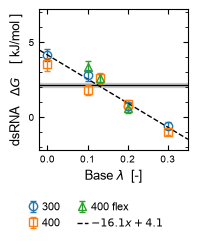

In [20]:
       
def load_data_ddx4_dsRNA_300_chains():
    dG_list = []
    dG_err_list = []
    sdir = './analysis/data/'

    ######################################################
    # 300 chains

    lambda_list = [0,0.1,0.2,0.3]
    for i,Lz_key in enumerate(['l00','l01','l02','l03']):
        name = 'DDX4-300_ds_acug24-15_direct_{:s}'.format(Lz_key)

        # computr c_sat
        csat = np.load(sdir+"conc_"+name+"_ds_acug24.npy")

        rna_dens_mean = csat[2]*1e3
        rna_dens_std = csat[3]*1e3
        rna_dil_mean = csat[0]*1e3
        rna_dil_std = csat[1]*1e3

        #ax.text(0, 1e2*0.9, 'Csat {0}$\pm${1} uM'.format(str(rna_dil_mean)[:3],str(rna_dil_std)[:3]),horizontalalignment='right')

        RT = 8.31*1e-3 * 293
        dG = -np.log(rna_dens_mean/rna_dil_mean) * RT 
        dG_list.append(dG)
        dG_err = error_prop(rna_dens_mean,rna_dil_mean,rna_dens_std,rna_dil_std) * RT
        dG_err_list.append(dG_err)
        print(name,dG)
    return lambda_list, dG_list, dG_err_list


def load_data_ddx4_dsRNA_400_chains():
    dG_list = []
    dG_err_list = []
    sdir = './analysis/data/'

    #lambda_list = [0,0.1,0.14,0.14,0.14,0.2,0.3]
    lambda_list = [0,0.1,0.13,0.2,0.3]
    for i,Lz_key in enumerate(['l00','l01','l013','l02','l03']):
        name = 'DDX4-400_ds_acug24-15_direct_{:s}'.format(Lz_key)

        # computr c_sat
        csat = np.load(sdir+"conc_"+name+"_ds_acug24.npy")

        rna_dens_mean = csat[2]*1e3
        rna_dens_std = csat[3]*1e3
        rna_dil_mean = csat[0]*1e3
        rna_dil_std = csat[1]*1e3

        #ax.text(0, 1e2*0.9, 'Csat {0}$\pm${1} uM'.format(str(rna_dil_mean)[:3],str(rna_dil_std)[:3]),horizontalalignment='right')

        RT = 8.31*1e-3 * 293
        dG = -np.log(rna_dens_mean/rna_dil_mean) * RT 
        dG_list.append(dG)
        dG_err = error_prop(rna_dens_mean,rna_dil_mean,rna_dens_std,rna_dil_std) * RT
        dG_err_list.append(dG_err)
        print(name,dG)
    return lambda_list, dG_list, dG_err_list


def load_data_ddx4_dsRNA_400_chains_flex():
    dG_list = []
    dG_err_list = []
    sdir = './analysis/data/'

    #lambda_list = [0.13] 
    lambda_list = [0.13, 0.1, 0.2]
    #lambda_list = [0.13, 0.1, 0.2]
    #for i,Lz_key in enumerate(['l013_k10','l013_k10_1','l013_k10_2','l01_k10','l02_k10']):
    for i,Lz_key in enumerate(['l013_k10','l01_k10','l02_k10']):
    #for i,Lz_key in enumerate(['l013_k10']):
    #for i,Lz_key in enumerate(['l013_k10','l01_k10','l02_k10']):
        name = 'DDX4-400_ds_acug24-15_direct_{:s}'.format(Lz_key)

        # computr c_sat
        csat = np.load(sdir+"conc_"+name+"_ds_acug24.npy")

        rna_dens_mean = csat[2]*1e3
        rna_dens_std = csat[3]*1e3
        rna_dil_mean = csat[0]*1e3
        rna_dil_std = csat[1]*1e3

        #ax.text(0, 1e2*0.9, 'Csat {0}$\pm${1} uM'.format(str(rna_dil_mean)[:3],str(rna_dil_std)[:3]),horizontalalignment='right')

        RT = 8.31*1e-3 * 293
        dG = -np.log(rna_dens_mean/rna_dil_mean) * RT 
        dG_list.append(dG)
        dG_err = error_prop(rna_dens_mean,rna_dil_mean,rna_dens_std,rna_dil_std) * RT
        dG_err_list.append(dG_err)
        print(name,"Delta G {0} pm {1}".format(dG,dG_err) )
    return lambda_list, dG_list, dG_err_list  

def load_linear_fit(lambda_list,dG_list):
    A = np.vstack([lambda_list, np.ones(len(lambda_list))]).T 
    a, b = np.linalg.lstsq(A, dG_list, rcond=None)[0]
    l_fit = (target_dG-b)/a
    print("lambda at target dG", l_fit)
    return a, b

def adjust_fig(ax__,param):
    [dx,dy,dw,dh] = param
    pos1 = ax__.get_position()  
    pos2 = [pos1.x0+dx, pos1.y0+dy, pos1.width+dw, pos1.height+dh] 
    ax__.set_position(pos2)
    

fig, ax = plt.subplots(1,1,figsize=(1.8,2.4))

# dsRNA data
target_dG = 2.13  
target_dG_std = 0.14 
## plot exp data (if match ddG)
#calvados dG_ss = -9.46 ± 0.16
# exp ddG = 11.19 ± 0.4 
print("target dG", "{0} pm {1} kj/mol".format(target_dG, (target_dG_std)))
ax.hlines(target_dG,-0.1,0.4,color='black',linestyle='solid',lw=1)
ax.axhspan(target_dG-target_dG_std, target_dG+target_dG_std, color='grey', alpha=0.3)

## 300 chians
lambda_list_300, dG_list_300, dG_err_list_300 = load_data_ddx4_dsRNA_300_chains()
ax.errorbar(lambda_list_300, dG_list_300, yerr=dG_err_list_300,
                lw=0, marker='o', ms=6, elinewidth=1, capsize=2, capthick=1,
                markerfacecolor='none', color=cmap(0),
                label='300')

## 400 chains
lambda_list_400, dG_list_400, dG_err_list_400 = load_data_ddx4_dsRNA_400_chains()
ax.errorbar(lambda_list_400, dG_list_400, yerr=dG_err_list_400,
                lw=0, marker='s', ms=6, elinewidth=1, capsize=2, capthick=1,
                markerfacecolor='none', color=cmap(1),
                label='400')

## 400 chains flex
lambda_list_400_flex, dG_list_400_flex, dG_err_list_400_flex = load_data_ddx4_dsRNA_400_chains_flex()
ax.errorbar(lambda_list_400_flex, dG_list_400_flex, yerr=dG_err_list_400_flex,
                lw=0, marker='^', ms=6, elinewidth=1, capsize=2, capthick=1,
                markerfacecolor='none', color=cmap(2),
                label='400 flex')



a, b = load_linear_fit(lambda_list_300+lambda_list_400+lambda_list_400_flex,
                       dG_list_300+dG_list_400+dG_list_400_flex
                      )
x1, x2 = -0.05, 0.35
ax.plot([x1,x2], [a*x1+b, a*x2+b],
        color='k',linestyle="dashed", lw=1,
        label="${:s}x+{:s}$".format(str(a)[:5],str(b)[0:3]))


ax.set_xlabel("Base $\lambda$  [-]", fontsize=9)
ax.set_ylabel("dsRNA   $\Delta G$    [ kJ/mol ]", fontsize=9)

ax.set_yticks(np.arange(-0,7,5)); ax.set_yticks(np.arange(-2,7.2,1),minor=True)
ax.set_xlim([-0.02,0.35])
#ax.set_ylim([-2.1,6])
ax.set_ylim([-2.2,7.2])

#ax.legend(edgecolor='k', fontsize=8, ncol=2, loc='lower left', handlelength=1.)
handles, labels = plt. gca (). get_legend_handles_labels ()
order = [1,2,3,0]
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], 
           edgecolor='k',
           frameon=False,
           fontsize=8, ncol=2, 
           bbox_to_anchor=(0.9, -0.3),
           handlelength=1.,
           handletextpad=0.3,
           columnspacing=1.5)


plt.tight_layout(pad=0.1)

plt.savefig("ddx4_dsrna_lambda_tuning.svg",dpi=300)
plt.show()

target dG 2.13 pm 0.14 kj/mol
DDX4-300_ds_acug24-15_direct_l00 4.136375156152282
DDX4-300_ds_acug24-15_direct_l01 2.7820488786982924
DDX4-300_ds_acug24-15_direct_l02 0.7152006176278999
DDX4-300_ds_acug24-15_direct_l03 -0.5698058626685962
DDX4-400_ds_acug24-15_direct_l00 3.527710535037769
DDX4-400_ds_acug24-15_direct_l01 1.823962799947311
DDX4-400_ds_acug24-15_direct_l013 2.5912429577358616
DDX4-400_ds_acug24-15_direct_l02 0.8805723145785619
DDX4-400_ds_acug24-15_direct_l03 -0.9756303806671044
DDX4-400_ds_acug24-15_direct_l013_k10 Delta G 2.6012774415918862 pm 0.2950842897076741
DDX4-400_ds_acug24-15_direct_l01_k10 Delta G 3.37102624822252 pm 0.36104231236661216
DDX4-400_ds_acug24-15_direct_l02_k10 Delta G 0.6187308934287962 pm 0.3326389512271728
lambda at target dG 0.12567233457145885
slop -16.104697456417437 intercept 4.153914926915014


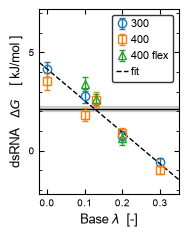

In [21]:
       
def load_data_ddx4_dsRNA_300_chains():
    dG_list = []
    dG_err_list = []
    sdir = './analysis/data/'

    ######################################################
    # 300 chains

    lambda_list = [0,0.1,0.2,0.3]
    for i,Lz_key in enumerate(['l00','l01','l02','l03']):
        name = 'DDX4-300_ds_acug24-15_direct_{:s}'.format(Lz_key)

        # computr c_sat
        csat = np.load(sdir+"conc_"+name+"_ds_acug24.npy")

        rna_dens_mean = csat[2]*1e3
        rna_dens_std = csat[3]*1e3
        rna_dil_mean = csat[0]*1e3
        rna_dil_std = csat[1]*1e3

        #ax.text(0, 1e2*0.9, 'Csat {0}$\pm${1} uM'.format(str(rna_dil_mean)[:3],str(rna_dil_std)[:3]),horizontalalignment='right')

        RT = 8.31*1e-3 * 293
        dG = -np.log(rna_dens_mean/rna_dil_mean) * RT 
        dG_list.append(dG)
        dG_err = error_prop(rna_dens_mean,rna_dil_mean,rna_dens_std,rna_dil_std) * RT
        dG_err_list.append(dG_err)
        print(name,dG)
    return lambda_list, dG_list, dG_err_list


def load_data_ddx4_dsRNA_400_chains():
    dG_list = []
    dG_err_list = []
    sdir = './analysis/data/'

    #lambda_list = [0,0.1,0.14,0.14,0.14,0.2,0.3]
    lambda_list = [0,0.1,0.13,0.2,0.3]
    for i,Lz_key in enumerate(['l00','l01','l013','l02','l03']):
        name = 'DDX4-400_ds_acug24-15_direct_{:s}'.format(Lz_key)

        # computr c_sat
        csat = np.load(sdir+"conc_"+name+"_ds_acug24.npy")

        rna_dens_mean = csat[2]*1e3
        rna_dens_std = csat[3]*1e3
        rna_dil_mean = csat[0]*1e3
        rna_dil_std = csat[1]*1e3

        #ax.text(0, 1e2*0.9, 'Csat {0}$\pm${1} uM'.format(str(rna_dil_mean)[:3],str(rna_dil_std)[:3]),horizontalalignment='right')

        RT = 8.31*1e-3 * 293
        dG = -np.log(rna_dens_mean/rna_dil_mean) * RT 
        dG_list.append(dG)
        dG_err = error_prop(rna_dens_mean,rna_dil_mean,rna_dens_std,rna_dil_std) * RT
        dG_err_list.append(dG_err)
        print(name,dG)
    return lambda_list, dG_list, dG_err_list


def load_data_ddx4_dsRNA_400_chains_flex():
    dG_list = []
    dG_err_list = []
    sdir = './analysis/data/'

    #lambda_list = [0.13] 
    lambda_list = [0.13, 0.1, 0.2]
    #lambda_list = [0.13, 0.1, 0.2]
    #for i,Lz_key in enumerate(['l013_k10','l013_k10_1','l013_k10_2','l01_k10','l02_k10']):
    for i,Lz_key in enumerate(['l013_k10','l01_k10','l02_k10']):
    #for i,Lz_key in enumerate(['l013_k10']):
    #for i,Lz_key in enumerate(['l013_k10','l01_k10','l02_k10']):
        name = 'DDX4-400_ds_acug24-15_direct_{:s}'.format(Lz_key)

        # computr c_sat
        csat = np.load(sdir+"conc_"+name+"_ds_acug24.npy")

        rna_dens_mean = csat[2]*1e3
        rna_dens_std = csat[3]*1e3
        rna_dil_mean = csat[0]*1e3
        rna_dil_std = csat[1]*1e3

        #ax.text(0, 1e2*0.9, 'Csat {0}$\pm${1} uM'.format(str(rna_dil_mean)[:3],str(rna_dil_std)[:3]),horizontalalignment='right')

        RT = 8.31*1e-3 * 293
        dG = -np.log(rna_dens_mean/rna_dil_mean) * RT 
        dG_list.append(dG)
        dG_err = error_prop(rna_dens_mean,rna_dil_mean,rna_dens_std,rna_dil_std) * RT
        dG_err_list.append(dG_err)
        print(name,"Delta G {0} pm {1}".format(dG,dG_err) )
    return lambda_list, dG_list, dG_err_list  

def load_linear_fit(lambda_list,dG_list):
    A = np.vstack([lambda_list, np.ones(len(lambda_list))]).T 
    a, b = np.linalg.lstsq(A, dG_list, rcond=None)[0]
    l_fit = (target_dG-b)/a
    print("lambda at target dG", l_fit)
    return a, b

def adjust_fig(ax__,param):
    [dx,dy,dw,dh] = param
    pos1 = ax__.get_position()  
    pos2 = [pos1.x0+dx, pos1.y0+dy, pos1.width+dw, pos1.height+dh] 
    ax__.set_position(pos2)
    

def pannel_base_dg(ax):

    # dsRNA data
    target_dG = 2.13  
    target_dG_std = 0.14 
    ## plot exp data (if match ddG)
    #calvados dG_ss = -9.46 ± 0.16
    # exp ddG = 11.19 ± 0.4 
    print("target dG", "{0} pm {1} kj/mol".format(target_dG, (target_dG_std)))
    ax.hlines(target_dG,-0.1,0.4,color='black',linestyle='solid',lw=1)
    ax.axhspan(target_dG-target_dG_std, target_dG+target_dG_std, color='grey', alpha=0.3)
    
    ## 300 chians
    lambda_list_300, dG_list_300, dG_err_list_300 = load_data_ddx4_dsRNA_300_chains()
    ax.errorbar(lambda_list_300, dG_list_300, yerr=dG_err_list_300,
                    lw=0, marker='o', ms=6, elinewidth=1, capsize=2, capthick=1,
                    markerfacecolor='none', color=cmap(0),
                    label='300')
    
    ## 400 chains
    lambda_list_400, dG_list_400, dG_err_list_400 = load_data_ddx4_dsRNA_400_chains()
    ax.errorbar(lambda_list_400, dG_list_400, yerr=dG_err_list_400,
                    lw=0, marker='s', ms=6, elinewidth=1, capsize=2, capthick=1,
                    markerfacecolor='none', color=cmap(1),
                    label='400')
    
    ## 400 chains flex
    lambda_list_400_flex, dG_list_400_flex, dG_err_list_400_flex = load_data_ddx4_dsRNA_400_chains_flex()
    ax.errorbar(lambda_list_400_flex, dG_list_400_flex, yerr=dG_err_list_400_flex,
                    lw=0, marker='^', ms=6, elinewidth=1, capsize=2, capthick=1,
                    markerfacecolor='none', color=cmap(2),
                    label='400 flex')
    
    
    
    a, b = load_linear_fit(lambda_list_300+lambda_list_400+lambda_list_400_flex,
                           dG_list_300+dG_list_400+dG_list_400_flex
                          )
    print("slop", a, "intercept", b)
    x1, x2 = -0.05, 0.35
    ax.plot([x1,x2], [a*x1+b, a*x2+b],
            color='k',linestyle="dashed", lw=1,
            label="fit")
    
    
    ax.set_xlabel("Base $\lambda$  [-]", fontsize=9)
    ax.set_ylabel("dsRNA   $\Delta G$    [ kJ/mol ]", fontsize=9)
    
    ax.set_yticks(np.arange(-0,7,5)); ax.set_yticks(np.arange(-2,7.2,1),minor=True)
    ax.set_xlim([-0.02,0.35])
    #ax.set_ylim([-2.1,6])
    ax.set_ylim([-2.2,7.2])
    
    #ax.legend(edgecolor='k', fontsize=8, ncol=2, loc='lower left', handlelength=1.)
    handles, labels = plt. gca (). get_legend_handles_labels ()
    order = [1,2,3,0]
    plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], 
               edgecolor='k',
               frameon=True,
               fontsize=8, ncol=1,
               #bbox_to_anchor=(0.9, -0.3),
               loc="upper right",
               handlelength=1.,
               handletextpad=0.3,
               columnspacing=1.5)

fig, ax = plt.subplots(1,1,figsize=(1.8,2.4))
pannel_base_dg(ax)
plt.show()

In [22]:
def pannel_ddx4_dsrna_01(ax):
    img = mpimg.imread("./figdata/ddx4_dsrna_l01_slab.png")
    ax.imshow(img)
    ax.axis("off")

def pannel_ddx4_dsrna_03(ax):
    img = mpimg.imread("./figdata/ddx4_dsrna_l03_slab.png")
    ax.imshow(img)
    ax.axis("off")

-104.0 104.0
-104.0 104.0
-104.0 104.0
-104.0 104.0
target dG 2.13 pm 0.14 kj/mol
DDX4-300_ds_acug24-15_direct_l00 4.136375156152282
DDX4-300_ds_acug24-15_direct_l01 2.7820488786982924
DDX4-300_ds_acug24-15_direct_l02 0.7152006176278999
DDX4-300_ds_acug24-15_direct_l03 -0.5698058626685962
DDX4-400_ds_acug24-15_direct_l00 3.527710535037769
DDX4-400_ds_acug24-15_direct_l01 1.823962799947311
DDX4-400_ds_acug24-15_direct_l013 2.5912429577358616
DDX4-400_ds_acug24-15_direct_l02 0.8805723145785619
DDX4-400_ds_acug24-15_direct_l03 -0.9756303806671044
DDX4-400_ds_acug24-15_direct_l013_k10 Delta G 2.6012774415918862 pm 0.2950842897076741
DDX4-400_ds_acug24-15_direct_l01_k10 Delta G 3.37102624822252 pm 0.36104231236661216
DDX4-400_ds_acug24-15_direct_l02_k10 Delta G 0.6187308934287962 pm 0.3326389512271728
lambda at target dG 0.12567233457145885
slop -16.104697456417437 intercept 4.153914926915014


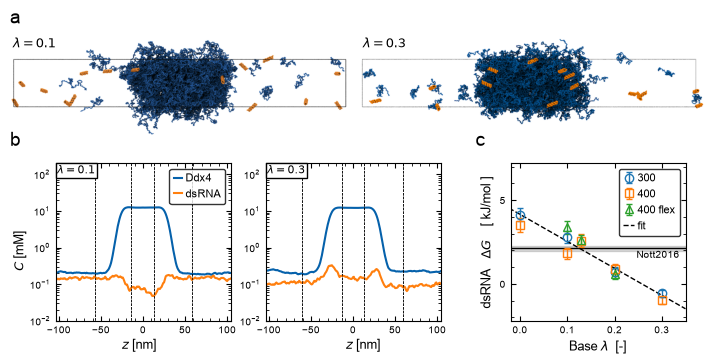

In [23]:
fig = plt.figure(figsize=(7, 3.5))

ax1 = fig.add_axes([-0.24, 0.63, 0.98, 0.98/2364*694])
pannel_ddx4_dsrna_01(ax1)

ax2 = fig.add_axes([0.244, 0.65, 1.01, 1.01/1728*454])
pannel_ddx4_dsrna_03(ax2)

ax3 = fig.add_axes([0.07, 0.10, 0.25, 0.45])
ax4 = fig.add_axes([0.37, 0.10, 0.25, 0.45])
pannel_ddx4_dsrna_dens_prof([ax3, ax4])

ax5 = fig.add_axes([0.72, 0.10, 0.25, 0.45])
pannel_base_dg(ax5)

fig.text(0.04, 0.88, r'$\lambda=0.1$', ha='center', fontsize=9)
fig.text(0.54, 0.88, r'$\lambda=0.3$', ha='center', fontsize=9)
fig.text(0.19, 0.02, r'$z$ [nm]', ha='center', fontsize=9)
fig.text(0.02, 0.3, r'$C$ [mM]', ha='center', va='center', rotation='vertical', fontsize=9)
fig.text(0.51, 0.02, r'$z$ [nm]', ha='center', fontsize=9)
    

fig.text(0.005, 0.95, "a", fontsize=14)
fig.text(0.005, 0.6, "b", fontsize=14)
fig.text(0.67, 0.6, "c", fontsize=14)
fig.text(0.9, 0.28, "Nott2016", fontsize=7)


plt.savefig("./figure3.pdf", dpi=300)
plt.show()

# Persistence length

In [24]:
k_list_n136 = [8,10,20]

corr_list_n136 = []
plen_list_n136 = []
plen_sem_list_n136 = []
for k in k_list_n136:
    corr = np.load('./analysis/data/single_dsACUG_n136_k{:d}_corr.npy'.format(k))
    data = np.load('./analysis/data/single_dsACUG_n136_k{:d}_plength.npz'.format(k))
    plen = data['mean']
    plen_sem = data['sem']    
    corr_list_n136.append(corr)
    plen_list_n136.append(plen)
    plen_sem_list_n136.append(plen_sem)
    


$k_{\mathrm{e}}=$20 [array(52.12517558), array(65.11865089), array(147.3755986)] [array(4.046176), array(3.65275677), array(5.70017874)]


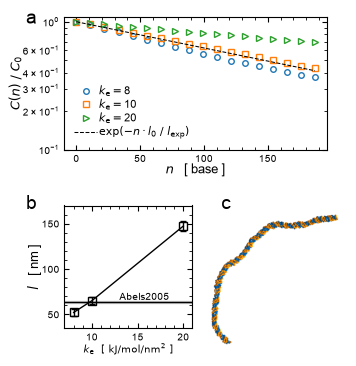

In [25]:
# figure 4
#fig, axs = plt.subplots(2,1,figsize=(3.2,3.5), gridspec_kw={'hspace': 0.5})
fig = plt.figure(figsize=(3.2,3.5))
ax0 = fig.add_axes([0.13, 0.59, 0.82, 0.38])
ax1 = fig.add_axes([0.13, 0.08, 0.40, 0.35])

xs = np.arange(0,len(corr))

ax = ax0
markers = ["o", "s", ">"]
for i,k in enumerate(k_list_n136):
    ax.plot(11*xs, 
            corr_list_n136[i], 
            label="$k_{\mathrm{e}}=$"+str(k), 
            marker=markers[i], 
            markerfacecolor='None', 
            lw=0,
            markersize=4,
           )


ax.plot(11*xs,np.exp(-(xs)*3.22/62),
        color='k', linestyle="dashed", lw=0.75,
        label="$\mathrm{exp}{(-n \cdot l_0~/~l_{\mathrm{exp}})}$")

ax.set_yscale("log")
ax.legend(fontsize=8, 
          frameon = False,
          edgecolor='k', 
          loc='lower left', 
          ncol=1, 
          handletextpad=0.2,
          labelspacing=0.2
         )
ax.set_ylabel("$C(n)~/~C_0$",fontsize=9, labelpad=0.1)
ax.set_xlabel("$n$   [ base ]", fontsize=9, labelpad=0.1)
ax.set_ylim([0.1,1.1])
ax.set_xticks(np.arange(0, 200, 50)); ax.set_xticks(np.arange(0,200,10),minor=True)


ax = ax1

ax.errorbar(k_list_n136, plen_list_n136, yerr=plen_sem_list_n136, 
            lw=1, marker='s', ms=6, elinewidth=1, capsize=2, capthick=1,
            markerfacecolor='none', color='k',label="n=15")
print("$k_{\mathrm{e}}=$"+str(k), plen_list_n136, plen_sem_list_n136)


ax.set_ylabel("$l$   [ nm ]", fontsize=9, labelpad=0.1)
ax.set_xlabel("$k_{\mathrm{e}}~~[~\mathrm{kJ}/\mathrm{mol}/\mathrm{nm}^2~]$", labelpad=0.1)

# AFM Abels 2005
plength = 63.8
plength_std = 0.7
ax.hlines(plength,0,35,color='black',linestyle='solid',lw=1)
ax.axhspan(plength-plength_std, plength+plength_std, color='grey', alpha=0.3)
ax.text(13,66,"Abels2005")

#ax.legend(fontsize=8,edgecolor='k', loc='upper left')
ax.set_xticks(np.arange(10,23,5)); ax.set_xticks(np.arange(7,23,1),minor=True)
ax.set_yticks(np.arange(50,150+1,50)); ax.set_yticks(np.arange(50,170,10),minor=True)
ax.set_ylim([35,170])
ax.set_xlim([7,21])


fig.text(0.01,0.95,"a",size=14)
fig.text(0.01,0.42,"b",size=14)
fig.text(0.62,0.42,"c",size=14)

plt.tight_layout(pad=0.1)

#pos = axs[1].get_position()
#axs[1].set_position([pos.x0, pos.y0, pos.width * 0.6, pos.height])

ax2 = fig.add_axes([0.44, 0.0, 0.58, 0.58/1143*1074])
img = mpimg.imread("./figdata/bp280_rna.png")
ax2.imshow(img)
ax2.axis("off")


plt.savefig("figure4.pdf",dpi=300)
plt.savefig("figure4.svg",dpi=300)

plt.show()

# CAPRIN1 simulation

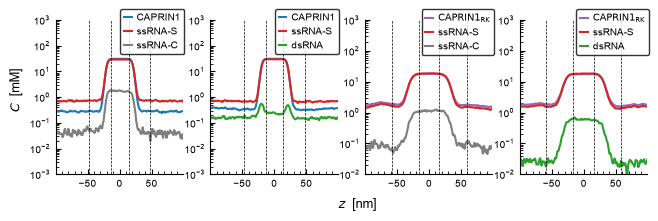

In [26]:
# 200 mM WT vs 80 mM Mutant
fig, axs = plt.subplots(1, 4, figsize=(6.2,1.8))
axs = axs.flat

label_dic = {'CAPRIN1_N623TN630T':'CAPRIN1',
             'CAPRIN1_N623TN630T_RK':r'$\mathrm{CAPRIN1}_{\mathrm{RK}}$',
             'CAPRIN1_N623TN630T_4RKM':r'$\mathrm{CAPRIN1}_{\mathrm{RK}}$',
             'sspolyR12': 'ssRNA-S', 
             'dspolyR12': 'dsRNA', 
             'label_sspolyR12':'ssRNA-C'}

color_dic = {'CAPRIN1_N623TN630T':cmap(0),
             'CAPRIN1_N623TN630T_RK':cmap(4),
             'CAPRIN1_N623TN630T_4RKM':cmap(4),
             'sspolyR12':cmap(3), 
             'dspolyR12':cmap(2), 
             'label_sspolyR12':cmap(7),
             'CAPRIN1':cmap(0),
             'CAPRIN1_RK':cmap(4),
             'CAPRIN1_4RKM':cmap(4),
             'ssRNA':cmap(3), 
             'dsRNA':cmap(2), 
             'lssRNA':cmap(7),
            }

def plot_caprin_hist(ax,name,comp_name_list, label_dic, color_dic, title=True, xlim=None,ylim=[1e-2,1e2],ncol=1,sdir="analysis/data/"):
    for i,comp_name in enumerate(comp_name_list):
        h = np.load(sdir+'hist_'+name+"_"+comp_name+'.npy')
        x = np.arange(0,len(h.mean(axis=0))) # bin size 1 nm
        x = x-np.mean(x) # centering z=0
        ax.plot(x,h.mean(axis=0),color=color_dic[comp_name],label=label_dic[comp_name])
    
    if title:
        ax.set_title(name,fontsize=8)
    ax.set_yscale('log')
    if xlim is not None:
        ax.set_xlim(xlim)
    else: 
        ax.set_xlim([x[0],x[-1]])
    ax.set_ylim(ylim)
    ax.legend(fontsize=7, 
              loc='upper right', 
              edgecolor='k', 
              ncol=ncol, 
              bbox_to_anchor=(1.05, 1.1),
              handlelength=0.8,
              handletextpad=0.5,)

    # plot bondary
    bb = np.load(sdir+"cutoff_"+name+".npy")
    ax.vlines(bb,ylim[0],ylim[-1],color='black',linestyle="dashed",lw=0.5)
    

# CAPRIN 1  + label_ssRNA
ax = axs[0]
name = 'CAPRIN1_N623TN630T-500_sspolyR12-500_label_sspolyR12-30_200mM'
plot_caprin_hist(ax, name,['CAPRIN1_N623TN630T','sspolyR12','label_sspolyR12'], label_dic, color_dic,
          title=False,xlim=None,ylim=[1e-3,1e3])
ax.set_xticks(np.arange(-50,100,50)); ax.set_xticks(np.arange(-100,100,10), minor=True)

# CAPRIN 1  + dsRNA
ax = axs[1]
name = 'CAPRIN1_N623TN630T-500_sspolyR12-500_dspolyR12-15_200mM'
plot_caprin_hist(ax, name,['CAPRIN1_N623TN630T','sspolyR12','dspolyR12'], label_dic, color_dic,
          title=False, xlim=None,ylim=[1e-3,1e3])
ax.set_xticks(np.arange(-50,100,50)); ax.set_xticks(np.arange(-100,100,10), minor=True)

ax = axs[2]
name = 'CAPRIN1_N623TN630T_RK-500_sspolyR12-500_label_sspolyR12-30_80mM'
plot_caprin_hist(ax, name,['CAPRIN1_N623TN630T_RK','sspolyR12','label_sspolyR12'], label_dic, color_dic,
          title=False, xlim=None,ylim=[1e-2,1e3])
ax.set_xticks(np.arange(-50,100,50)); ax.set_xticks(np.arange(-100,100,10), minor=True)

# CAPRIN 1  RK + dsRNA
ax = axs[3]
name = 'CAPRIN1_N623TN630T_RK-500_sspolyR12-500_dspolyR12-15_80mM'
plot_caprin_hist(ax, name,['CAPRIN1_N623TN630T_RK','sspolyR12','dspolyR12'], label_dic, color_dic,
          title=False, xlim=None,ylim=[1e-2,1e3])

ax.set_xticks(np.arange(-50,100,50)); ax.set_xticks(np.arange(-100,100,10), minor=True)

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(top=False, right=False)
    ax.tick_params(axis="both", which="minor", top=False, right=False)

fig.text(0.5, -0.1, "$z$  [nm]", size=9)
fig.text(-0.03, 0.45, "$C$  [mM]", rotation=90, size=9)
plt.tight_layout(pad=0.1)
plt.savefig('caprin1_density.pdf', dpi=300, bbox_inches='tight')
plt.savefig('caprin1_density.svg', dpi=300, bbox_inches='tight')
plt.show()

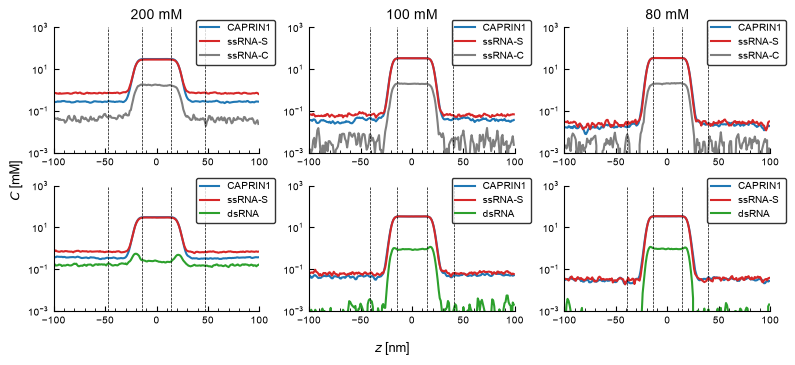

In [27]:
# Supplementary 

fig, axs = plt.subplots(2, 3, figsize=(8,3*1.2))
#axs = axs.flat

label_dic = {'CAPRIN1_N623TN630T':'CAPRIN1',
             'CAPRIN1_N623TN630T_RK':r'$\mathrm{CAPRIN1}_{\mathrm{RK}}$',
             'CAPRIN1_N623TN630T_4RKM':r'$\mathrm{CAPRIN1}_{\mathrm{RK}}$',
             'sspolyR12': 'ssRNA-S', 
             'dspolyR12': 'dsRNA', 
             'label_sspolyR12': 'ssRNA-C'}

color_dic = {'CAPRIN1_N623TN630T':cmap(0),
             'CAPRIN1_N623TN630T_RK':cmap(4),
             'CAPRIN1_N623TN630T_4RKM':cmap(4),
             'sspolyR12':cmap(3), 
             'dspolyR12':cmap(2), 
             'label_sspolyR12':cmap(7),
             'CAPRIN1':cmap(0),
             'CAPRIN1_RK':cmap(4),
             'CAPRIN1_4RKM':cmap(4),
             'ssRNA':cmap(3), 
             'ssRNA-S':cmap(3), 
             'dsRNA':cmap(2), 
             'lssRNA':cmap(7),
             'ssRNA-C':cmap(3), 
            }

def plot_caprin_hist(ax,name,comp_name_list, label_dic, color_dic, title=True, xlim=None,ylim=[1e-2,1e2],ncol=1,sdir="analysis/data/"):
    for i,comp_name in enumerate(comp_name_list):
        h = np.load(sdir+'hist_'+name+"_"+comp_name+'.npy')
        x = np.arange(0,len(h.mean(axis=0))) # bin size 1 nm
        x = x-np.mean(x) # centering z=0
        ax.plot(x,h.mean(axis=0),color=color_dic[comp_name],label=label_dic[comp_name])
    
    if title:
        ax.set_title(name,fontsize=8)
    ax.set_yscale('log')
    if xlim is not None:
        ax.set_xlim(xlim)
    else: 
        ax.set_xlim([x[0],x[-1]])
    ax.set_ylim(ylim)
    ax.legend(fontsize=7, loc='upper right', edgecolor='k', ncol=ncol, bbox_to_anchor=(1.1, 1.1),) 

    # plot bondary
    bb = np.load(sdir+"cutoff_"+name+".npy")
    ax.vlines(bb,ylim[0],ylim[-1],color='black',linestyle="dashed",lw=0.5)
    

# CAPRIN 1  + label_ssRNA @ 200 mM
ax = axs[0,0]
name = 'CAPRIN1_N623TN630T-500_sspolyR12-500_label_sspolyR12-30_200mM'
plot_caprin_hist(ax, name,['CAPRIN1_N623TN630T','sspolyR12','label_sspolyR12'], label_dic, color_dic,
          title=False,xlim=None,ylim=[1e-3,1e3])
ax.set_xticks(np.arange(-100,110,50)); ax.set_xticks(np.arange(-100,110,10), minor=True)

# CAPRIN 1  + dsRNA @ 200 mM
ax = axs[1,0]
name = 'CAPRIN1_N623TN630T-500_sspolyR12-500_dspolyR12-15_200mM'
plot_caprin_hist(ax, name,['CAPRIN1_N623TN630T','sspolyR12','dspolyR12'], label_dic, color_dic,
          title=False, xlim=None,ylim=[1e-3,1e3])
ax.set_xticks(np.arange(-100,110,50)); ax.set_xticks(np.arange(-100,110,10), minor=True)

# CAPRIN 1  + label_ssRNA @ 100 mM
ax = axs[0,1]
name = 'CAPRIN1_N623TN630T-500_sspolyR12-500_label_sspolyR12-30_100mM'
plot_caprin_hist(ax, name,['CAPRIN1_N623TN630T','sspolyR12','label_sspolyR12'], label_dic, color_dic,
          title=False,xlim=None,ylim=[1e-3,1e3])
ax.set_xticks(np.arange(-100,110,50)); ax.set_xticks(np.arange(-100,110,10), minor=True)

# CAPRIN 1  + dsRNA @ 100 mM
ax = axs[1,1]
name = 'CAPRIN1_N623TN630T-500_sspolyR12-500_dspolyR12-15_100mM'
plot_caprin_hist(ax, name,['CAPRIN1_N623TN630T','sspolyR12','dspolyR12'], label_dic, color_dic,
          title=False, xlim=None,ylim=[1e-3,1e3])
ax.set_xticks(np.arange(-100,110,50)); ax.set_xticks(np.arange(-100,110,10), minor=True)

# CAPRIN 1  + label_ssRNA @ 80 mM
ax = axs[0,2]
name = 'CAPRIN1_N623TN630T-500_sspolyR12-500_label_sspolyR12-30_80mM'
plot_caprin_hist(ax, name,['CAPRIN1_N623TN630T','sspolyR12','label_sspolyR12'], label_dic, color_dic,
          title=False,xlim=None,ylim=[1e-3,1e3])
ax.set_xticks(np.arange(-100,110,50)); ax.set_xticks(np.arange(-100,110,10), minor=True)

# CAPRIN 1  + dsRNA @ 80 mM
ax = axs[1,2]
name = 'CAPRIN1_N623TN630T-500_sspolyR12-500_dspolyR12-15_80mM'
plot_caprin_hist(ax, name,['CAPRIN1_N623TN630T','sspolyR12','dspolyR12'], label_dic, color_dic,
          title=False, xlim=None,ylim=[1e-3,1e3])
ax.set_xticks(np.arange(-100,110,50)); ax.set_xticks(np.arange(-100,110,10), minor=True)


axs[0,0].set_title("200 mM", fontsize=10)
axs[0,1].set_title("100 mM", fontsize=10)
axs[0,2].set_title("80 mM", fontsize=10)
ax.set_xticks(np.arange(-100,110,50)); ax.set_xticks(np.arange(-100,110,10), minor=True)


fig.supylabel("$C$ [mM] ", fontsize=9)
fig.supxlabel("$z$ [nm] ", fontsize=9)

for ax in axs.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(top=False, right=False)
    ax.tick_params(axis="x", which="minor", top=False)
    ax.tick_params(axis="y", which="minor", right=False)

plt.tight_layout(pad=1)
plt.savefig('sup_caprin1_density.pdf', dpi=300)
plt.show()

In [28]:
label_dic = {'CAPRIN1_N623TN630T':'CAPRIN1',
             'CAPRIN1_N623TN630T_RK':r'$\mathrm{CAPRIN1}_{\mathrm{RK}}$',
             'CAPRIN1_N623TN630T_4RKM':r'$\mathrm{CAPRIN1}_{\mathrm{RK}}$',
             'sspolyR12': 'ssRNA-S', 
             'dspolyR12': 'dsRNA', 
             'label_sspolyR12':'ssRNA-C'}

color_dic = {'CAPRIN1_N623TN630T':cmap(0),
             'CAPRIN1_N623TN630T_RK':cmap(4),
             'CAPRIN1_N623TN630T_4RKM':cmap(4),
             'sspolyR12':cmap(3), 
             'dspolyR12':cmap(2), 
             'label_sspolyR12':cmap(7),
             'CAPRIN1':cmap(0),
             'CAPRIN1_RK':cmap(4),
             'CAPRIN1_4RKM':cmap(4),
             'ssRNA':cmap(3), 
             'ssRNA-S':cmap(3), 
             'dsRNA':cmap(2), 
             'lssRNA':cmap(7),
             'ssRNA-C':cmap(3), 
            }

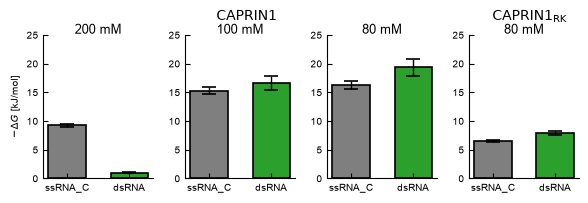

In [29]:
# Partition energy
# WT 200, 150, 80 mM

def caprin_simulation_load_dG_from_conc_file(name,client,RT=8.31*1e-3 * 297.15,sdir="analysis/data/"):
    
    conc = np.load(sdir+"conc_"+name+"_"+client+".npy")

    dens_mean = conc[2]*1e3
    dens_std = conc[3]*1e3
    dil_mean = conc[0]*1e3
    dil_std = conc[1]*1e3

    dG = -np.log(dens_mean/dil_mean) * RT 
    dG_err = error_prop(dens_mean,dil_mean,dens_std,dil_std) * RT
    
    if dil_mean < 1e-4:
        print("reach lower limit in dil_mean ....", name)
        dG = -25
        dG_err = 0
        
    return dG, dG_err


# plot
fig, axs = plt.subplots(1,4, figsize=(6,2))
axs = axs.flat

x = np.arange(2)

# CAPRIN1 WT 200 mM
name = 'CAPRIN1_N623TN630T-500_sspolyR12-500_label_sspolyR12-30_200mM'
ss_dg, ss_dg_err = caprin_simulation_load_dG_from_conc_file(name, 'label_sspolyR12', RT=8.31*1e-3 * 297.15)

name = 'CAPRIN1_N623TN630T-500_sspolyR12-500_dspolyR12-15_200mM'
ds_dg, ds_dg_err = caprin_simulation_load_dG_from_conc_file(name, 'dspolyR12', RT=8.31*1e-3 * 297.15)

ax = axs[0]
ax.bar(x, [-ss_dg, -ds_dg], yerr=[ss_dg_err, ds_dg_err], 
       width=.6,error_kw=dict(lw=1, capsize=5, capthick=1.2), 
       linewidth=1.2, edgecolor='k',color=[cmap(7), cmap(2)])

ax.set_ylabel(r"$-\Delta G$ [kJ/mol]")
ax.set_xticks(x)
ax.set_xticklabels(['ssRNA_C', 'dsRNA'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
ax.set_title('200 mM', color='k', fontsize=9, y=0.95)
ax.set_ylim([0,25])


# CAPRIN1 WT 100 mM
name = 'CAPRIN1_N623TN630T-500_sspolyR12-500_label_sspolyR12-30_100mM'
ss_dg, ss_dg_err = caprin_simulation_load_dG_from_conc_file(name, 'label_sspolyR12', RT=8.31*1e-3 * 297.15)

name = 'CAPRIN1_N623TN630T-500_sspolyR12-500_dspolyR12-15_100mM'
ds_dg, ds_dg_err = caprin_simulation_load_dG_from_conc_file(name, 'dspolyR12', RT=8.31*1e-3 * 297.15)

ax = axs[1]
ax.bar(x, [-ss_dg, -ds_dg], yerr=[ss_dg_err, ds_dg_err], 
       width=.6,error_kw=dict(lw=1, capsize=5, capthick=1.2), 
       linewidth=1.2, edgecolor='k',color=[cmap(7), cmap(2)])

#ax.set_ylabel(r"$-\Delta G$ [kJ/mol]")
ax.set_xticks(x)
ax.set_xticklabels(['ssRNA_C', 'dsRNA'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
ax.set_title('100 mM', color='k', fontsize=9, y=0.95)
ax.set_ylim([0,25])

# CAPRIN1 WT 80 mM
name = 'CAPRIN1_N623TN630T-500_sspolyR12-500_label_sspolyR12-30_80mM'
ss_dg, ss_dg_err = caprin_simulation_load_dG_from_conc_file(name, 'label_sspolyR12', RT=8.31*1e-3 * 297.15)

name = 'CAPRIN1_N623TN630T-500_sspolyR12-500_dspolyR12-15_80mM'
ds_dg, ds_dg_err = caprin_simulation_load_dG_from_conc_file(name, 'dspolyR12', RT=8.31*1e-3 * 297.15)

ax = axs[2]
ax.bar(x, [-ss_dg, -ds_dg], yerr=[ss_dg_err, ds_dg_err],
       width=.6,error_kw=dict(lw=1, capsize=5, capthick=1.2), 
       linewidth=1.2, edgecolor='k',color=[cmap(7), cmap(2)])


ax.set_xticks(x)
ax.set_xticklabels(['ssRNA_C', 'dsRNA'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
ax.set_title('80 mM', color='k', fontsize=9, y=0.95)
ax.set_ylim([0,25])


# CAPRIN1_RK @ 80 mM
name = 'CAPRIN1_N623TN630T_RK-500_sspolyR12-500_label_sspolyR12-30_80mM'
ss_dg, ss_dg_err = caprin_simulation_load_dG_from_conc_file(name, 'label_sspolyR12', RT=8.31*1e-3 * 297.15)

name = 'CAPRIN1_N623TN630T_RK-500_sspolyR12-500_dspolyR12-15_80mM'
ds_dg, ds_dg_err = caprin_simulation_load_dG_from_conc_file(name, 'dspolyR12', RT=8.31*1e-3 * 297.15)

ax = axs[3]
ax.bar(x, [-ss_dg, -ds_dg], yerr=[ss_dg_err, ds_dg_err],
       width=.6,error_kw=dict(lw=1, capsize=5, capthick=1.2), 
       linewidth=1.2, edgecolor='k',color=[cmap(7), cmap(2)])


#ax.set_ylabel(r"$-\Delta G$ into RK [kJ/mol]")
ax.set_xticks(x)
ax.set_xticklabels(['ssRNA_C', 'dsRNA'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
ax.set_title('80 mM', fontsize=9, y=0.95)
ax.set_ylim([0,25])


fig.text(0.37, 0.94, r'$\mathrm{CAPRIN1}$', fontsize=10)
fig.text(0.83, 0.94, r'$\mathrm{CAPRIN1}_{\mathrm{RK}}$', fontsize=10)

plt.tight_layout(pad=1.5)

plt.savefig('sup_caprin1_dG.pdf', dpi=300)
plt.show()



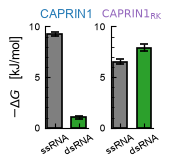

In [30]:
# Partition energy

def caprin_simulation_load_dG_from_conc_file(name,client,RT=8.31*1e-3 * 297.15,sdir="analysis/data/"):
    
    conc = np.load(sdir+"conc_"+name+"_"+client+".npy")

    dens_mean = conc[2]*1e3
    dens_std = conc[3]*1e3
    dil_mean = conc[0]*1e3
    dil_std = conc[1]*1e3

    dG = -np.log(dens_mean/dil_mean) * RT 
    dG_err = error_prop(dens_mean,dil_mean,dens_std,dil_std) * RT

    return dG, dG_err


# plot
fig, axs = plt.subplots(1,2, figsize=(1.5,1.5))
axs = axs.flat

x = np.arange(2)


# CAPRIN1 WT
name = 'CAPRIN1_N623TN630T-500_sspolyR12-500_label_sspolyR12-30_200mM'
ss_dg, ss_dg_err = caprin_simulation_load_dG_from_conc_file(name, 'label_sspolyR12', RT=8.31*1e-3 * 297.15)

name = 'CAPRIN1_N623TN630T-500_sspolyR12-500_dspolyR12-15_200mM'
ds_dg, ds_dg_err = caprin_simulation_load_dG_from_conc_file(name, 'dspolyR12', RT=8.31*1e-3 * 297.15)

ax = axs[0]
ax.bar(x, [-ss_dg, -ds_dg], yerr=[ss_dg_err, ds_dg_err], 
       width=.6,error_kw=dict(lw=1, capsize=3, capthick=1.2), 
       linewidth=1.2, edgecolor='k',color=[cmap(7), cmap(2)])

ax.set_ylabel(r"$-\Delta G$   [kJ/mol]",fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(['ssRNA', 'dsRNA'],rotation=30)
#ax.spines['top'].set_visible(False)
#ax.spines['right'].set_visible(False)
#ax.tick_params(top=False, right=False)
ax.set_title('CAPRIN1', color=cmap(0), fontsize=8.5)
ax.set_ylim([0,10])



# CAPRIN1_RK
name = 'CAPRIN1_N623TN630T_RK-500_sspolyR12-500_label_sspolyR12-30_80mM'
ss_dg, ss_dg_err = caprin_simulation_load_dG_from_conc_file(name, 'label_sspolyR12', RT=8.31*1e-3 * 297.15)

name = 'CAPRIN1_N623TN630T_RK-500_sspolyR12-500_dspolyR12-15_80mM'
ds_dg, ds_dg_err = caprin_simulation_load_dG_from_conc_file(name, 'dspolyR12', RT=8.31*1e-3 * 297.15)

ax = axs[1]
ax.bar(x, [-ss_dg, -ds_dg], yerr=[ss_dg_err, ds_dg_err],
       width=.6,error_kw=dict(lw=1, capsize=3, capthick=1.2), 
       linewidth=1.2, edgecolor='k',color=[cmap(7), cmap(2)])


#ax.set_ylabel(r"$-\Delta G$ into RK [kJ/mol]")
ax.set_xticks(x)
ax.set_xticklabels(['ssRNA', 'dsRNA'],rotation=30)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
ax.set_title(r'$\mathrm{CAPRIN1}_{\mathrm{RK}}$', color=cmap(4), fontsize=8.)
ax.set_ylim([0,10])

for ax in axs:
    ax.set_yticks(np.arange(0,11,5))
    ax.set_yticks(np.arange(0,11,1), minor=True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(top=False, right=False)
    ax.tick_params(top=False, right=False, which='both')


plt.tight_layout(pad=0.1)

plt.savefig('caprin1_dG.pdf', dpi=300, bbox_inches='tight')
plt.savefig('caprin1_dG.svg', dpi=300, bbox_inches='tight')

plt.show()

CAPRIN1_N623TN630T label_sspolyR12 (np.float64(-5.1585988666477265), np.float64(0.033916660124120805), np.float64(-3.1909523744043313), np.float64(0.025758087705691757), np.float64(-1.9676464922433932), np.float64(0.013047031602551745))
sspolyR12 label_sspolyR12 (np.float64(0.4408717575843643), np.float64(0.007960817016581157), np.float64(-0.1732853308999093), np.float64(0.008570881252608515), np.float64(0.6141570884842736), np.float64(0.008233975738059913))
label_sspolyR12 label_sspolyR12 (np.float64(0.008220774316196265), np.float64(0.0013299327489186294), np.float64(-0.0039897799923140674), np.float64(0.0014866360629127206), np.float64(0.012210554308510334), np.float64(0.00145838763831749))
CAPRIN1_N623TN630T dspolyR12 (np.float64(-2.6208116923724876), np.float64(0.018450312160356298), np.float64(-1.1935432946927855), np.float64(0.012123845948050946), np.float64(-1.4272683976797016), np.float64(0.011020880072325318))
sspolyR12 dspolyR12 (np.float64(0.2812206213838183), np.float64(0.

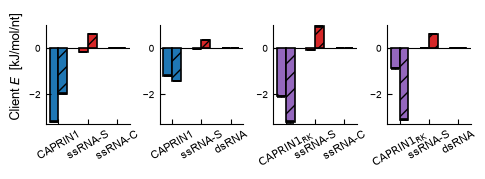

In [31]:
# CAPRIN1 + ssRNA + dsRNA
# per nucleotide

def load_mchain_interaction(name, scaffold_name, client_name):
    path = './analysis/data/'
    ah = np.load(path+"mchain_ahmap_{0}_{1}_{2}.npy".format(name, scaffold_name, client_name)).sum(axis=1)
    dh = np.load(path+"mchain_dhmap_{0}_{1}_{2}.npy".format(name, scaffold_name, client_name)).sum(axis=1)
    e = ah + dh
    
    # energy
    e_mean = e.mean(axis=0)
    block_e = BlockAnalysis(e)
    block_e.SEM()
    e_std = block_e.sem
    
    # ah potential
    ah_mean = ah.mean(axis=0)
    block_ah = BlockAnalysis(ah)
    block_ah.SEM()
    ah_std = block_ah.sem
    
    # dh potential
    dh_mean = dh.mean(axis=0)
    block_dh = BlockAnalysis(dh)
    block_dh.SEM()
    dh_std = block_dh.sem
    
    if client_name=='label_sspolyR12':
        nn = 12
        
    elif client_name=='dspolyR12':
        nn = 24
        
    return e_mean/nn, e_std/nn, ah_mean/nn, ah_std/nn, dh_mean/nn, dh_std/nn 
        

fig, axs = plt.subplots(1, 4, figsize=(4.5,1.5))
axs = axs.flat

name = 'CAPRIN1_N623TN630T-500_sspolyR12-500_label_sspolyR12-15_200mM'
ax = axs[0]

scaffold_name = 'CAPRIN1_N623TN630T'
client_name = 'label_sspolyR12'
a0 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a0)

scaffold_name = 'sspolyR12'
client_name = 'label_sspolyR12'
a1 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a1)

scaffold_name = 'label_sspolyR12'
client_name = 'label_sspolyR12'
a2 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a2)

dx = 0.3
x = np.arange(3)*2
ax.bar(x-dx, 
       [ a0[2], a1[2], a2[2] ], 
       yerr=[ a0[3], a1[3], a2[3] ], 
       width=.6,error_kw=dict(lw=1, capsize=3, capthick=1.2), 
       linewidth=1.2, edgecolor='k',
       color=[color_dic['CAPRIN1'], color_dic['ssRNA'], color_dic['ssRNA-C']]
      )
ax.bar(x+dx, 
       [ a0[4], a1[4], a2[4] ], 
       yerr=[ a0[5], a1[5], a2[5] ], 
       width=.6,error_kw=dict(lw=1, capsize=3, capthick=1.2), 
       linewidth=1.2, edgecolor='k', hatch='//',
       color=[color_dic['CAPRIN1'], color_dic['ssRNA'], color_dic['ssRNA-C']]
      )

ax.axhline(y=0, color='black', linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
ax.set_xticks(x)
ax.set_xticklabels(['CAPRIN1', 'ssRNA-S', 'ssRNA-C'], fontsize=8, rotation=30)



name = 'CAPRIN1_N623TN630T-500_sspolyR12-500_dspolyR12-15_200mM'
ax = axs[1]

scaffold_name = 'CAPRIN1_N623TN630T'
client_name = 'dspolyR12'
a0 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a0)

scaffold_name = 'sspolyR12'
client_name = 'dspolyR12'
a1 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a1)

scaffold_name = 'dspolyR12'
client_name = 'dspolyR12'
a2 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a2)

x = np.arange(3)*2
ax.bar(x-dx, 
       [ a0[2], a1[2], a2[2] ], 
       yerr=[ a0[3], a1[3], a2[3] ], 
       width=.6,error_kw=dict(lw=1, capsize=3, capthick=1.2), 
       linewidth=1.2, edgecolor='k',
       color=[color_dic['CAPRIN1'], color_dic['ssRNA'], color_dic['dsRNA']]
      )
ax.bar(x+dx, 
       [ a0[4], a1[4], a2[4] ], 
       yerr=[ a0[5], a1[5], a2[5] ], 
       width=.6,error_kw=dict(lw=1, capsize=3, capthick=1.2), 
       linewidth=1.2, edgecolor='k', hatch='//',
       color=[color_dic['CAPRIN1'], color_dic['ssRNA'], color_dic['dsRNA']]
      )

ax.axhline(y=0, color='black', linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
ax.set_xticks(x)
ax.set_xticklabels(['CAPRIN1', 'ssRNA-S', 'dsRNA'], fontsize=8, rotation=30)

 
    
name = 'CAPRIN1_N623TN630T_RK-500_sspolyR12-500_label_sspolyR12-15_80mM'
ax = axs[2]

scaffold_name = 'CAPRIN1_N623TN630T_RK'
client_name = 'label_sspolyR12'
a0 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a0)

scaffold_name = 'sspolyR12'
client_name = 'label_sspolyR12'
a1 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a1)

scaffold_name = 'label_sspolyR12'
client_name = 'label_sspolyR12'
a2 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a2)

x = np.arange(3)*2
ax.bar(x-dx, 
       [ a0[2], a1[2], a2[2] ], 
       yerr=[a0[3], a1[3], a2[3] ], 
       width=.6,error_kw=dict(lw=1, capsize=3, capthick=1.2), 
       linewidth=1.2, edgecolor='k',
       color=[color_dic['CAPRIN1_RK'], color_dic['ssRNA-S'], color_dic['ssRNA-C']]
      )
ax.bar(x+dx, 
       [ a0[4], a1[4], a2[4] ], 
       yerr=[ a0[5], a1[5], a2[5] ], 
       width=.6,error_kw=dict(lw=1, capsize=3, capthick=1.2), 
       linewidth=1.2, edgecolor='k', hatch='//',
       color=[color_dic['CAPRIN1_RK'], color_dic['ssRNA-S'], color_dic['ssRNA-C']]
       )

ax.axhline(y=0, color='black', linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
ax.set_xticks(x)
ax.set_xticklabels([r'$\mathrm{CAPRIN1}_{\mathrm{RK}}$', 'ssRNA-S', 'ssRNA-C'], fontsize=8, rotation=30)


    
name = 'CAPRIN1_N623TN630T_RK-500_sspolyR12-500_dspolyR12-15_80mM'
ax = axs[3]

scaffold_name = 'CAPRIN1_N623TN630T_RK'
client_name = 'dspolyR12'
a0 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a0)

scaffold_name = 'sspolyR12'
client_name = 'dspolyR12'
a1 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a1)

scaffold_name = 'dspolyR12'
client_name = 'dspolyR12'
a2 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a2)

x = np.arange(3)*2
ax.bar(x-dx, 
       [ a0[2], a1[2], a2[2] ], 
       yerr=[ a0[3], a1[3], a2[3] ], 
       width=.6,error_kw=dict(lw=1, capsize=3, capthick=1.2), 
       linewidth=1.2, edgecolor='k',
       color=[color_dic['CAPRIN1_RK'], color_dic['ssRNA'], color_dic['dsRNA']]
      )
ax.bar(x+dx, 
       [ a0[4], a1[4], a2[4] ], 
       yerr=[ a0[5], a1[5], a2[5] ], 
       width=.6,error_kw=dict(lw=1, capsize=3, capthick=1.2), 
       linewidth=1.2, edgecolor='k', hatch='//',
       color=[color_dic['CAPRIN1_RK'], color_dic['ssRNA'], color_dic['dsRNA']]
      )
ax.axhline(y=0, color='black', linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
ax.set_xticks(x)
ax.set_xticklabels([r'$\mathrm{CAPRIN1}_{\mathrm{RK}}$', 'ssRNA-S', 'dsRNA'], fontsize=8, rotation=30)

 
for ax in axs:
    ax.set_ylim([-3.3, 1])

fig.text(-0.04, 0.35, "Client $E$  [kJ/mol/nt] ", fontsize=9, rotation=90)

plt.tight_layout(pad=0.1)
plt.savefig('caprin1_energy.pdf', dpi=300, bbox_inches='tight')
plt.savefig('caprin1_energy.svg', dpi=300, bbox_inches='tight')
plt.show()

CAPRIN1_N623TN630T label_sspolyR12 (np.float64(-5.1585988666477265), np.float64(0.033916660124120805), np.float64(-3.1909523744043313), np.float64(0.025758087705691757), np.float64(-1.9676464922433932), np.float64(0.013047031602551745))
sspolyR12 label_sspolyR12 (np.float64(0.4408717575843643), np.float64(0.007960817016581157), np.float64(-0.1732853308999093), np.float64(0.008570881252608515), np.float64(0.6141570884842736), np.float64(0.008233975738059913))
label_sspolyR12 label_sspolyR12 (np.float64(0.008220774316196265), np.float64(0.0013299327489186294), np.float64(-0.0039897799923140674), np.float64(0.0014866360629127206), np.float64(0.012210554308510334), np.float64(0.00145838763831749))
CAPRIN1_N623TN630T dspolyR12 (np.float64(-2.6208116923724876), np.float64(0.018450312160356298), np.float64(-1.1935432946927855), np.float64(0.012123845948050946), np.float64(-1.4272683976797016), np.float64(0.011020880072325318))
sspolyR12 dspolyR12 (np.float64(0.2812206213838183), np.float64(0.

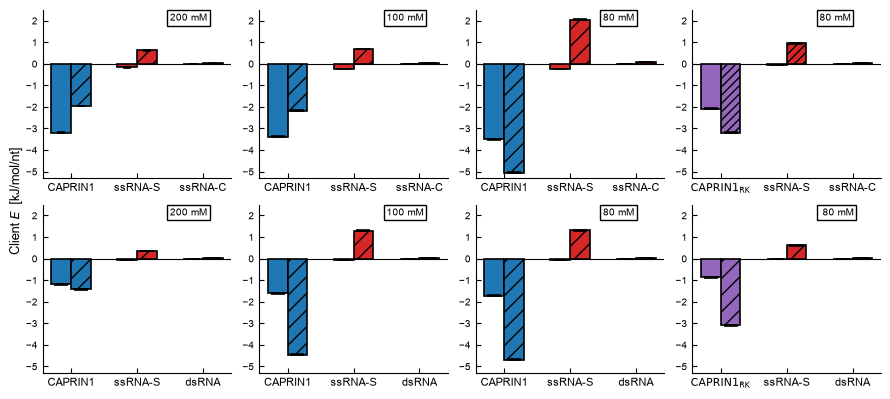

In [32]:
# CAPRIN1 + ssRNA + dsRNA
# per nucleotide
# supplementary

def load_mchain_interaction(name, scaffold_name, client_name):
    path = './analysis/data/'
    ah = np.load(path+"mchain_ahmap_{0}_{1}_{2}.npy".format(name, scaffold_name, client_name)).sum(axis=1)
    dh = np.load(path+"mchain_dhmap_{0}_{1}_{2}.npy".format(name, scaffold_name, client_name)).sum(axis=1)
    e = ah + dh
    
    # energy
    e_mean = e.mean(axis=0)
    block_e = BlockAnalysis(e)
    block_e.SEM()
    e_std = block_e.sem
    
    # ah potential
    ah_mean = ah.mean(axis=0)
    block_ah = BlockAnalysis(ah)
    block_ah.SEM()
    ah_std = block_ah.sem
    
    # dh potential
    dh_mean = dh.mean(axis=0)
    block_dh = BlockAnalysis(dh)
    block_dh.SEM()
    dh_std = block_dh.sem
    
    if client_name=='label_sspolyR12':
        nn = 12
        
    elif client_name=='dspolyR12':
        nn = 24
        
    return e_mean/nn, e_std/nn, ah_mean/nn, ah_std/nn, dh_mean/nn, dh_std/nn 
        

fig, axs = plt.subplots(2, 4, figsize=(9,4))
#axs = axs.flat

#CAPRIN1 200 mM
name = 'CAPRIN1_N623TN630T-500_sspolyR12-500_label_sspolyR12-15_200mM'
ax = axs[0,0]

scaffold_name = 'CAPRIN1_N623TN630T'
client_name = 'label_sspolyR12'
a0 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a0)

scaffold_name = 'sspolyR12'
client_name = 'label_sspolyR12'
a1 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a1)

scaffold_name = 'label_sspolyR12'
client_name = 'label_sspolyR12'
a2 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a2)

dx = 0.3
x = np.arange(3)*2
ax.bar(x-dx, 
       [ a0[2], a1[2], a2[2] ], 
       yerr=[ a0[3], a1[3], a2[3] ], 
       width=.6,error_kw=dict(lw=1, capsize=3, capthick=1.2), 
       linewidth=1.2, edgecolor='k',
       color=[color_dic['CAPRIN1'], color_dic['ssRNA'], color_dic['ssRNA-C']]
      )
ax.bar(x+dx, 
       [ a0[4], a1[4], a2[4] ], 
       yerr=[ a0[5], a1[5], a2[5] ], 
       width=.6,error_kw=dict(lw=1, capsize=3, capthick=1.2), 
       linewidth=1.2, edgecolor='k', hatch='//',
       color=[color_dic['CAPRIN1'], color_dic['ssRNA'], color_dic['ssRNA-C']]
      )

ax.axhline(y=0, color='black', linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
ax.set_xticks(x)
ax.set_xticklabels(['CAPRIN1', 'ssRNA-S', 'ssRNA-C'], fontsize=8)



name = 'CAPRIN1_N623TN630T-500_sspolyR12-500_dspolyR12-15_200mM'
ax = axs[1,0]

scaffold_name = 'CAPRIN1_N623TN630T'
client_name = 'dspolyR12'
a0 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a0)

scaffold_name = 'sspolyR12'
client_name = 'dspolyR12'
a1 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a1)

scaffold_name = 'dspolyR12'
client_name = 'dspolyR12'
a2 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a2)

x = np.arange(3)*2
ax.bar(x-dx, 
       [ a0[2], a1[2], a2[2] ], 
       yerr=[ a0[3], a1[3], a2[3] ], 
       width=.6,error_kw=dict(lw=1, capsize=5, capthick=1.2), 
       linewidth=1.2, edgecolor='k',
       color=[color_dic['CAPRIN1'], color_dic['ssRNA'], color_dic['dsRNA']]
      )
ax.bar(x+dx, 
       [ a0[4], a1[4], a2[4] ], 
       yerr=[ a0[5], a1[5], a2[5] ], 
       width=.6,error_kw=dict(lw=1, capsize=5, capthick=1.2), 
       linewidth=1.2, edgecolor='k', hatch='//',
       color=[color_dic['CAPRIN1'], color_dic['ssRNA'], color_dic['dsRNA']]
      )

ax.axhline(y=0, color='black', linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
ax.set_xticks(x)
ax.set_xticklabels(['CAPRIN1', 'ssRNA-S', 'dsRNA'], fontsize=8)


#CAPRIN1 100 mM
name = 'CAPRIN1_N623TN630T-500_sspolyR12-500_label_sspolyR12-30_100mM'
ax = axs[0,1]

scaffold_name = 'CAPRIN1_N623TN630T'
client_name = 'label_sspolyR12'
a0 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a0)

scaffold_name = 'sspolyR12'
client_name = 'label_sspolyR12'
a1 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a1)

scaffold_name = 'label_sspolyR12'
client_name = 'label_sspolyR12'
a2 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a2)

dx = 0.3
x = np.arange(3)*2
ax.bar(x-dx, 
       [ a0[2], a1[2], a2[2] ], 
       yerr=[ a0[3], a1[3], a2[3] ], 
       width=.6,error_kw=dict(lw=1, capsize=5, capthick=1.2), 
       linewidth=1.2, edgecolor='k',
       color=[color_dic['CAPRIN1'], color_dic['ssRNA'], color_dic['ssRNA-C']]
      )
ax.bar(x+dx, 
       [ a0[4], a1[4], a2[4] ], 
       yerr=[ a0[5], a1[5], a2[5] ], 
       width=.6,error_kw=dict(lw=1, capsize=5, capthick=1.2), 
       linewidth=1.2, edgecolor='k', hatch='//',
       color=[color_dic['CAPRIN1'], color_dic['ssRNA'], color_dic['ssRNA-C']]
      )

ax.axhline(y=0, color='black', linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
ax.set_xticks(x)
ax.set_xticklabels(['CAPRIN1', 'ssRNA-S', 'ssRNA-C'], fontsize=8)


name = 'CAPRIN1_N623TN630T-500_sspolyR12-500_dspolyR12-15_100mM'
ax = axs[1,1]

scaffold_name = 'CAPRIN1_N623TN630T'
client_name = 'dspolyR12'
a0 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a0)

scaffold_name = 'sspolyR12'
client_name = 'dspolyR12'
a1 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a1)

scaffold_name = 'dspolyR12'
client_name = 'dspolyR12'
a2 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a2)

x = np.arange(3)*2
ax.bar(x-dx, 
       [ a0[2], a1[2], a2[2] ], 
       yerr=[ a0[3], a1[3], a2[3] ], 
       width=.6,error_kw=dict(lw=1, capsize=5, capthick=1.2), 
       linewidth=1.2, edgecolor='k',
       color=[color_dic['CAPRIN1'], color_dic['ssRNA'], color_dic['dsRNA']]
      )
ax.bar(x+dx, 
       [ a0[4], a1[4], a2[4] ], 
       yerr=[ a0[5], a1[5], a2[5] ], 
       width=.6,error_kw=dict(lw=1, capsize=5, capthick=1.2), 
       linewidth=1.2, edgecolor='k', hatch='//',
       color=[color_dic['CAPRIN1'], color_dic['ssRNA'], color_dic['dsRNA']]
      )

ax.axhline(y=0, color='black', linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
ax.set_xticks(x)
ax.set_xticklabels(['CAPRIN1', 'ssRNA-S', 'dsRNA'], fontsize=8)

 
#CAPRIN1 80 mM
name = 'CAPRIN1_N623TN630T-500_sspolyR12-500_label_sspolyR12-30_80mM'
ax = axs[0,2]

scaffold_name = 'CAPRIN1_N623TN630T'
client_name = 'label_sspolyR12'
a0 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a0)

scaffold_name = 'sspolyR12'
client_name = 'label_sspolyR12'
a1 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a1)

scaffold_name = 'label_sspolyR12'
client_name = 'label_sspolyR12'
a2 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a2)

dx = 0.3
x = np.arange(3)*2
ax.bar(x-dx, 
       [ a0[2], a1[2], a2[2] ], 
       yerr=[ a0[3], a1[3], a2[3] ], 
       width=.6,error_kw=dict(lw=1, capsize=5, capthick=1.2), 
       linewidth=1.2, edgecolor='k',
       color=[color_dic['CAPRIN1'], color_dic['ssRNA'], color_dic['ssRNA-C']]
      )
ax.bar(x+dx, 
       [ a0[4], a1[4], a2[4] ], 
       yerr=[ a0[5], a1[5], a2[5] ], 
       width=.6,error_kw=dict(lw=1, capsize=5, capthick=1.2), 
       linewidth=1.2, edgecolor='k', hatch='//',
       color=[color_dic['CAPRIN1'], color_dic['ssRNA'], color_dic['ssRNA-C']]
      )

ax.axhline(y=0, color='black', linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
ax.set_xticks(x)
ax.set_xticklabels(['CAPRIN1', 'ssRNA-S', 'ssRNA-C'], fontsize=8)


name = 'CAPRIN1_N623TN630T-500_sspolyR12-500_dspolyR12-15_80mM'
ax = axs[1,2]

scaffold_name = 'CAPRIN1_N623TN630T'
client_name = 'dspolyR12'
a0 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a0)

scaffold_name = 'sspolyR12'
client_name = 'dspolyR12'
a1 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a1)

scaffold_name = 'dspolyR12'
client_name = 'dspolyR12'
a2 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a2)

x = np.arange(3)*2
ax.bar(x-dx, 
       [ a0[2], a1[2], a2[2] ], 
       yerr=[ a0[3], a1[3], a2[3] ], 
       width=.6,error_kw=dict(lw=1, capsize=5, capthick=1.2), 
       linewidth=1.2, edgecolor='k',
       color=[color_dic['CAPRIN1'], color_dic['ssRNA-S'], color_dic['dsRNA']]
      )
ax.bar(x+dx, 
       [ a0[4], a1[4], a2[4] ], 
       yerr=[ a0[5], a1[5], a2[5] ], 
       width=.6,error_kw=dict(lw=1, capsize=5, capthick=1.2), 
       linewidth=1.2, edgecolor='k', hatch='//',
       color=[color_dic['CAPRIN1'], color_dic['ssRNA-S'], color_dic['dsRNA']]
      )

ax.axhline(y=0, color='black', linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
ax.set_xticks(x)
ax.set_xticklabels(['CAPRIN1', 'ssRNA-S', 'dsRNA'], fontsize=8)


#CAPRIN1 RK 200 mM
name = 'CAPRIN1_N623TN630T_RK-500_sspolyR12-500_label_sspolyR12-15_80mM'
ax = axs[0,3]

scaffold_name = 'CAPRIN1_N623TN630T_RK'
client_name = 'label_sspolyR12'
a0 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a0)

scaffold_name = 'sspolyR12'
client_name = 'label_sspolyR12'
a1 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a1)

scaffold_name = 'label_sspolyR12'
client_name = 'label_sspolyR12'
a2 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a2)

x = np.arange(3)*2
ax.bar(x-dx, 
       [ a0[2], a1[2], a2[2] ], 
       yerr=[a0[3], a1[3], a2[3] ], 
       width=.6,error_kw=dict(lw=1, capsize=5, capthick=1.2), 
       linewidth=1.2, edgecolor='k',
       color=[color_dic['CAPRIN1_RK'], color_dic['ssRNA-S'], color_dic['ssRNA-C']]
      )
ax.bar(x+dx, 
       [ a0[4], a1[4], a2[4] ], 
       yerr=[ a0[5], a1[5], a2[5] ], 
       width=.6,error_kw=dict(lw=1, capsize=5, capthick=1.2), 
       linewidth=1.2, edgecolor='k', hatch='////',
       color=[color_dic['CAPRIN1_RK'], color_dic['ssRNA-S'], color_dic['ssRNA-C']]
       )

ax.axhline(y=0, color='black', linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
ax.set_xticks(x)
ax.set_xticklabels([r'$\mathrm{CAPRIN1}_{\mathrm{RK}}$', 'ssRNA-S', 'ssRNA-C'], fontsize=8)


    
name = 'CAPRIN1_N623TN630T_RK-500_sspolyR12-500_dspolyR12-15_80mM'
ax = axs[1,3]

scaffold_name = 'CAPRIN1_N623TN630T_RK'
client_name = 'dspolyR12'
a0 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a0)

scaffold_name = 'sspolyR12'
client_name = 'dspolyR12'
a1 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a1)

scaffold_name = 'dspolyR12'
client_name = 'dspolyR12'
a2 = load_mchain_interaction(name, scaffold_name, client_name)
print(scaffold_name, client_name, a2)

x = np.arange(3)*2
ax.bar(x-dx, 
       [ a0[2], a1[2], a2[2] ], 
       yerr=[ a0[3], a1[3], a2[3] ], 
       width=.6,error_kw=dict(lw=1, capsize=5, capthick=1.2), 
       linewidth=1.2, edgecolor='k',
       color=[color_dic['CAPRIN1_RK'], color_dic['ssRNA-S'], color_dic['dsRNA']]
      )
ax.bar(x+dx, 
       [ a0[4], a1[4], a2[4] ], 
       yerr=[ a0[5], a1[5], a2[5] ], 
       width=.6,error_kw=dict(lw=1, capsize=5, capthick=1.2), 
       linewidth=1.2, edgecolor='k', hatch='//',
       color=[color_dic['CAPRIN1_RK'], color_dic['ssRNA-S'], color_dic['dsRNA']]
      )
ax.axhline(y=0, color='black', linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
ax.set_xticks(x)
ax.set_xticklabels([r'$\mathrm{CAPRIN1}_{\mathrm{RK}}$', 'ssRNA-S', 'dsRNA'], fontsize=8)

 
for ax in axs.flat:
    ax.set_ylim([-5.3, 2.5])
    

axs[0,0].text( 3.,2,"200 mM", bbox=dict(facecolor='none', edgecolor='k', pad=2.0) )
axs[1,0].text( 3.,2,"200 mM", bbox=dict(facecolor='none', edgecolor='k', pad=2.0) )
axs[0,1].text( 3.,2,"100 mM", bbox=dict(facecolor='none', edgecolor='k', pad=2.0) )
axs[1,1].text( 3.,2,"100 mM", bbox=dict(facecolor='none', edgecolor='k', pad=2.0) )
axs[0,2].text( 3.,2, "80 mM", bbox=dict(facecolor='none', edgecolor='k', pad=2.0) )
axs[1,2].text( 3.,2, "80 mM", bbox=dict(facecolor='none', edgecolor='k', pad=2.0) )
axs[0,3].text( 3.,2, "80 mM", bbox=dict(facecolor='none', edgecolor='k', pad=2.0) )
axs[1,3].text( 3.,2," 80 mM", bbox=dict(facecolor='none', edgecolor='k', pad=2.0) )

fig.supylabel("Client $E$  [kJ/mol/nt] ", fontsize=9)

plt.tight_layout(pad=1)


plt.savefig('sup_caprin1_energy.pdf', dpi=300)
plt.show()

# DNA ======================================================

In [33]:
k_list_dna = [15, 20, 25, 30]

c_list_dna = []
lp_list_dna = []
lp_sem_list_dna = []
for k in k_list_dna:
    corr = np.load('./analysis/data/single_dsACTG_n136_k{:d}_corr.npy'.format(k))
    data = np.load('./analysis/data/single_dsACTG_n136_k{:d}_plength.npz'.format(k))
    plen = data['mean']
    plen_sem = data['sem']    
    c_list_dna.append(corr)
    lp_list_dna.append(plen)
    lp_sem_list_dna.append(plen_sem)
    

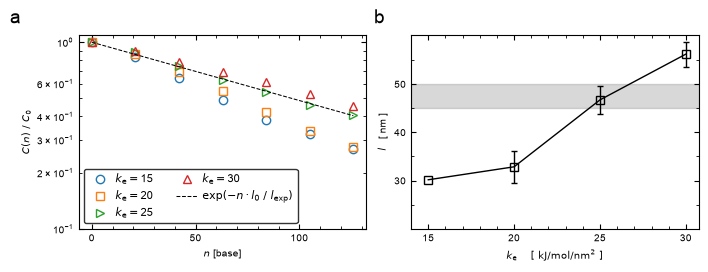

In [34]:
fig, axs = plt.subplots(1,2,figsize=(7,2.5))

ax = axs[0]

xs = np.arange(0,len(corr)) 

markers = ["o", "s", ">", "^", "p"]
for i,k in enumerate(k_list_dna):
    ax.plot(21*xs, c_list_dna[i], 
            label="$k_{\mathrm{e}}=$"+str(k), 
            marker=markers[i], markerfacecolor='None', lw=0)

pitch_2 = 3.4*2 # two turns
ax.plot(21*xs,np.exp(-(xs)*pitch_2/45),
        color='k',linestyle="dashed", lw=0.75,
        label="$\mathrm{exp}{(-n \cdot l_0~/~l_{\mathrm{exp}})}$")

ax.set_yscale("log")
ax.legend(fontsize=8, edgecolor='k', loc='lower left', ncol=2, handletextpad=0.4)
ax.set_ylabel("$C$")
ax.set_xlabel("Distance [base]")
ax.set_ylim([0.1,1.1])
ax.set_xticks(np.arange(0, 150, 50)); ax.set_xticks(np.arange(10,140,10),minor=True)
ax.set_ylabel("$C(n)~/~C_0$")
ax.set_xlabel("$n$ [base]")

ax = axs[1]

ax.errorbar(k_list_dna, lp_list_dna , yerr=lp_sem_list_dna, 
            lw=1, marker='s', ms=6, elinewidth=1, capsize=2, capthick=1,
            markerfacecolor='none', color='k',label="n=15")

ax.set_ylabel("$l$   [ nm ]")
ax.set_xlabel("$k_{\mathrm{e}}~~~~[~\mathrm{kJ}/\mathrm{mol}/\mathrm{nm}^2~]$")

#plength = 63.8
#plength_std = 0.7
#ax.hlines(plength,0,35,color='black',linestyle='solid',lw=1)
ax.axhspan(45, 50, color='grey', alpha=0.3)
#ax.text(17,66,"Abels 2005")

ax.set_xticks(np.arange(15,31,5)); ax.set_xticks(np.arange(14,31,1),minor=True)
ax.set_yticks(np.arange(30,60,10)); ax.set_yticks(np.arange(20,60,5),minor=True)
#ax.set_ylim([35,150])
#ax.set_xlim([5,21])

fig.text(0, 1.0, "a",fontsize=14)
fig.text(0.52, 1.0, "b",fontsize=14)
plt.tight_layout()
plt.savefig("sup_single_dna.pdf",dpi=300)
plt.savefig("sup_single_dna.svg",dpi=300)

plt.show()

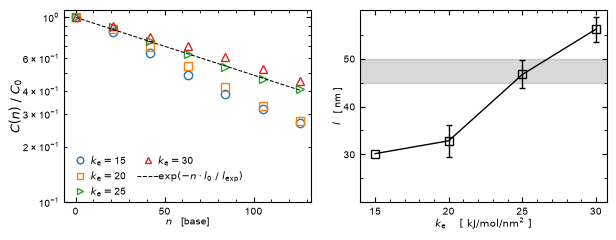

In [35]:
def plot_dan_onechain(axs):
    ax = axs[0]
    
    xs = np.arange(0,len(corr)) 
    
    markers = ["o", "s", ">", "^", "p"]
    for i,k in enumerate(k_list_dna):
        ax.plot(21*xs, c_list_dna[i], 
                label="$k_{\mathrm{e}}=$"+str(k), 
                marker=markers[i], markerfacecolor='None', lw=0)
    
    pitch_2 = 3.4*2 # two turns
    ax.plot(21*xs,np.exp(-(xs)*pitch_2/45),
            color='k',linestyle="dashed", lw=0.75,
            label="$\mathrm{exp}{(-n \cdot l_0~/~l_{\mathrm{exp}})}$")
    
    ax.set_yscale("log")
    ax.legend(fontsize=7.5, edgecolor='k', loc='lower left', 
              ncol=2, handletextpad=0.01, 
              markerscale=0.8, columnspacing=1, 
              frameon=False, borderpad=0.01)
    ax.set_ylabel("$C(n)~/~C_0$",fontsize=9, labelpad=0.1)
    ax.set_xlabel("$n$   [base]", labelpad=0.1)
    ax.set_ylim([0.1,1.1])
    ax.set_xticks(np.arange(0, 150, 50)); ax.set_xticks(np.arange(10,140,10),minor=True)
    
    ax = axs[1]
    
    ax.errorbar(k_list_dna, lp_list_dna , yerr=lp_sem_list_dna, 
                lw=1, marker='s', ms=6, elinewidth=1, capsize=2, capthick=1,
                markerfacecolor='none', color='k',label="n=15")
    
    ax.set_ylabel("$l$   [ nm ]", labelpad=0.1)
    ax.set_xlabel("$k_{\mathrm{e}}~~~~[~\mathrm{kJ}/\mathrm{mol}/\mathrm{nm}^2~]$", labelpad=0.1)
    
    ax.axhspan(45, 50, color='grey', alpha=0.3)
    
    ax.set_xticks(np.arange(15,31,5)); ax.set_xticks(np.arange(14,31,1),minor=True)
    ax.set_yticks(np.arange(30,60,10)); ax.set_yticks(np.arange(20,60,5),minor=True)


fig, axs = plt.subplots(1,2,figsize=(7,2.5))
plot_dan_onechain(axs)
plt.show()

In [36]:
# density profules shown for each simulation

def ddx4_dna_plot_density_profile(ax, name, comp_name, title, title_on=True, sdir='./analysis/data/'):
    #print(comp_name)
    h = np.load(sdir+"hist_"+name+"_"+comp_name+'.npy')
    x = np.arange(0,len(h.mean(axis=0)))                   # bin size 1 nm
    x = x-np.mean(x)                                       # centering z=0
    
    # DDX4 in blue
    if comp_name is "DDX4":
        ax.plot(x, h.mean(axis=0), label="Ddx4", color=blue2)
    
    # RNA in red
    elif comp_name is "ssACTG24":
        ax.plot(x, h.mean(axis=0), label="DNA", color=cmap(3))

    elif comp_name is "dsACTG24":
        ax.plot(x, h.mean(axis=0), label="DNA", color=cmap(1))
        
    # boundary line   
    bb = np.load(sdir+"cutoff_"+name+".npy")
    ax.vlines(bb,1e-3,2*1e2,color='black',linestyle="dashed",lw=0.5)
    
    # axis setting
    ax.set_ylim([1e-3, 2*1e2])
    ax.set_xlim([x[0], x[-1]])
    ax.set_yscale('log')
    
    if title_on:
        ax.text(1, 1, title, ha='right', va='top', transform=ax.transAxes, fontsize=legend_fontsize, 
                  bbox=dict(boxstyle="square,pad=0.15", facecolor="white", edgecolor="black", linewidth=1) )

In [37]:
## phase diagram
# load phase diagram 
# produce dilute and dense phase plots 


#  800 chain, dsRNA 8 chain
ssdna_pro_dil = []
ssdna_pro_den = []
ssdna_dna_dil = []
ssdna_dna_den = []
ssdna_dG = []
ssdna_interpolate = [] 
for run_id in ["_1","_2", "_3", "_4"]:
    a0, a1, a2, a3 = load_phase_diagram_data("DDX4-800_ssACTG24-8"+run_id, ddx4_exp = 162.5, rna_name = 'ssACTG24')
    ssdna_pro_dil.append(a0[0])
    ssdna_pro_den.append(a0[2])
    ssdna_dna_dil.append(a1[0])
    ssdna_dna_den.append(a1[2])
    ssdna_dG.append(a2[0])
    ssdna_interpolate.append(a3)
        
n_runs = 4
rows = []
row = {
    'Name': "DDX4-800_ssACTG-8",
    'Pro dilute (μM)': format_with_error(np.mean(ssdna_pro_dil), np.std(ssdna_pro_dil)/np.sqrt(n_runs), decimal_places),
    'Pro dense (μM)': format_with_error(np.mean(ssdna_pro_den),  np.std(ssdna_pro_den)/np.sqrt(n_runs), decimal_places),
    'RNA dilute (μM)': format_with_error(np.mean(ssdna_dna_dil), np.std(ssdna_dna_dil)/np.sqrt(n_runs), decimal_places),
    'RNA dense (μM)': format_with_error(np.mean(ssdna_dna_den),  np.std(ssdna_dna_den)/np.sqrt(n_runs), decimal_places),
    'ΔG (kJ/mol)': format_with_error(np.mean(ssdna_dG),          np.std(ssdna_dG)/np.sqrt(n_runs),      decimal_places),
}
rows.append(row)


#  400 chain, dsRNA 15 chain
a0, a1, a2, a3 = load_phase_diagram_data("DDX4-400_dsACTG24-15", ddx4_exp = 162.5, rna_name = 'dsACTG24')
row = {
    'Name': "DDX4-400_dsACTG-15",
    'Pro dilute (μM)': format_with_error(a0[0],  a0[1], decimal_places),
    'Pro dense (μM)':  format_with_error(a0[2],  a0[3], decimal_places),
    'RNA dilute (μM)': format_with_error(a1[0],  a1[1], decimal_places),
    'RNA dense (μM)':  format_with_error(a1[2],  a1[3], decimal_places),
    'ΔG (kJ/mol)':     format_with_error(a2[0],  a2[1], decimal_places),
}
rows.append(row)


# show table
df = pd.DataFrame(rows)
display(df)



conc_DDX4-800_ssACTG24-8_1
Pro [np.float64(190.69091998428271), np.float64(11.517659573371892), np.float64(12352.2534083875), np.float64(26.675968126998665)]
RNA [np.float64(2.9252284566175493), np.float64(0.5288381305981681), np.float64(103.43454940211433), np.float64(4.824876151074916)]
RNA dG [np.float64(-8.681548177195108), np.float64(0.454597915140315)]
interpolated RNA conc 2.6922443949765427
conc_DDX4-800_ssACTG24-8_2
Pro [np.float64(156.22620216139012), np.float64(8.488756644487708), np.float64(12342.307883560146), np.float64(29.500416395557114)]
RNA [np.float64(3.4239675604015956), np.float64(1.1818608548635887), np.float64(111.18506827181415), np.float64(4.55633186733624)]
RNA dG [np.float64(-8.474172862012034), np.float64(0.846339609473095)]
interpolated RNA conc 3.47944653866591
conc_DDX4-800_ssACTG24-8_3
Pro [np.float64(141.9640442308111), np.float64(8.392216674275616), np.float64(12304.596842753464), np.float64(26.88146590556258)]
RNA [np.float64(2.327180615305926), np.fl

,Name,Pro dilute (μM),Pro dense (μM),RNA dilute (μM),RNA dense (μM),ΔG (kJ/mol)
0,DDX4-800_ssACTG-8,162.16 ± 8.88,12328.20 ± 9.83,2.56 ± 0.35,105.12 ± 1.95,-9.14 ± 0.34
1,DDX4-400_dsACTG-15,181.33 ± 12.64,12512.36 ± 28.60,185.83 ± 1.71,3.19 ± 1.42,9.90 ± 1.08


In [38]:
key_list = ["", "_l02", "_l03", "_l04", "_l06", "_l07"]
sdir = './analysis/data/'

for key in key_list:
    name = 'DDX4-400_dsACTG24-15{0}'.format(key)
    csat = np.load(sdir+"conc_"+name+"_dsACTG24.npy")

    dsdna_dens_mean = csat[2]*1e3
    dsdna_dens_std = csat[3]*1e3
    dsdna_dil_mean = csat[0]*1e3
    dsdna_dil_std = csat[1]*1e3

    RT = 8.31*1e-3 * 293
    dG = -np.log(dsdna_dens_mean/dsdna_dil_mean) * RT 
    dG_err = error_prop(dsdna_dens_mean, dsdna_dil_mean, dsdna_dens_std, dsdna_dil_std) * RT
    print(name,"Delta G {0} pm {1}".format(dG,dG_err) )


DDX4-400_dsACTG24-15 Delta G 9.895754278894152 pm 1.0821366178403464
DDX4-400_dsACTG24-15_l02 Delta G 9.223413382461244 pm 1.0264721368784233
DDX4-400_dsACTG24-15_l03 Delta G 7.945240283590906 pm 0.8411411210967781
DDX4-400_dsACTG24-15_l04 Delta G 5.928522154648137 pm 0.6108537936180305
DDX4-400_dsACTG24-15_l06 Delta G 2.7366040974918744 pm 0.3795591723787062
DDX4-400_dsACTG24-15_l07 Delta G 1.278649877873659 pm 0.24535414446509332


target dG 2.13 pm 0.14 kj/mol
DDX4-400_dsACTG24-15 : 9.895754278894152 pm 1.0821366178403464
DDX4-400_dsACTG24-15_l04 : 5.928522154648137 pm 0.6108537936180305
DDX4-400_dsACTG24-15_l06 : 2.7366040974918744 pm 0.3795591723787062
DDX4-400_dsACTG24-15_l065 : 2.219773143737506 pm 0.314199810676043
DDX4-400_dsACTG24-15_l07 : 1.278649877873659 pm 0.24535414446509332
lambda at target dG 0.6474845627987902


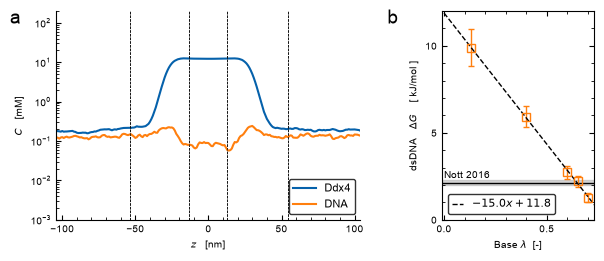

In [39]:
def load_data_ddx4_dsDNA():
    dG_list = []
    dG_err_list = []
    sdir = './analysis/data/'

    lambda_list = [0.13, 0.4, 0.6, 0.65, 0.7]
    for i,Lz_key in enumerate(['','_l04','_l06', '_l065', '_l07']):
        name = 'DDX4-400_dsACTG24-15{:s}'.format(Lz_key)

        # computr c_sat
        csat = np.load(sdir+"conc_"+name+"_dsACTG24.npy".format(key))

        rna_dens_mean = csat[2]*1e3
        rna_dens_std = csat[3]*1e3
        rna_dil_mean = csat[0]*1e3
        rna_dil_std = csat[1]*1e3

        RT = 8.31*1e-3 * 293
        dG = -np.log(rna_dens_mean/rna_dil_mean) * RT 
        dG_list.append(dG)
        dG_err = error_prop(rna_dens_mean,rna_dil_mean,rna_dens_std,rna_dil_std) * RT
        dG_err_list.append(dG_err)
        print(name, ":", dG, "pm", dG_err)
    return lambda_list, dG_list, dG_err_list

def load_linear_fit(lambda_list,dG_list):
    A = np.vstack([lambda_list, np.ones(len(lambda_list))]).T 
    a, b = np.linalg.lstsq(A, dG_list, rcond=None)[0]
    l_fit = (target_dG-b)/a
    print("lambda at target dG", l_fit)
    return a, b

def adjust_fig(ax__,param):
    [dx,dy,dw,dh] = param
    pos1 = ax__.get_position()  
    pos2 = [pos1.x0+dx, pos1.y0+dy, pos1.width+dw, pos1.height+dh] 
    ax__.set_position(pos2)
    
 
fig, axs = plt.subplots(1,2,figsize=(6, 2.5), constrained_layout=True, gridspec_kw={'width_ratios': [2, 1]})

ax = axs[0]
ddx4_dna_plot_density_profile(ax, name, 'DDX4', "", title_on=False) 
ddx4_dna_plot_density_profile(ax, name, 'dsACTG24', "DDX4 (400)$-$dsDNA (15), l065", title_on=False)

ax.legend(fontsize=8, edgecolor='k', loc="lower right")
ax.set_xlabel("$z$   [nm]")
ax.set_ylabel("$C$   [mM]")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
ax.tick_params(axis="both", which="minor", top=False, right=False)
ax.set_xticks(np.arange(-100,110,50)); ax.set_xticks(np.arange(-100,110,10),minor=True)

ax = axs[1]
## exp data
dG_exp = 1.9
dG_exp_err = 0.4

print("target dG", "{0} pm {1} kj/mol".format(target_dG, (target_dG_std)))
ax.hlines(target_dG, -0.1, 0.73, color='black', linestyle='solid', lw=1)
ax.axhspan(target_dG-target_dG_std, target_dG+target_dG_std, color='grey', alpha=0.3)

## simulation data
lambda_list_dsDNA, dG_list_dsDNA, dG_err_list_dsDNA = load_data_ddx4_dsDNA()
ax.errorbar(lambda_list_dsDNA, dG_list_dsDNA, yerr=dG_err_list_dsDNA,
            lw=0, marker='s', ms=6, elinewidth=1, capsize=2, capthick=1,
            markerfacecolor='none', color=cmap(1))


a, b = load_linear_fit(lambda_list_dsDNA, dG_list_dsDNA) 
ax.plot([0,1.13], [b, 1.13*a+b],
        color='k',linestyle="dashed", lw=1,
        label="${:s}x+{:s}$".format(str(a)[:5],str(b)[0:4]))


ax.set_xlabel("Base $\lambda$  [-]")
ax.set_ylabel("dsDNA   $\Delta G$    [ kJ/mol ]")

ax.set_xticks(np.arange(-0,0.73,0.5)); ax.set_xticks(np.arange(0,0.73,0.1),minor=True)
ax.set_yticks(np.arange(-0,12,5)); ax.set_yticks(np.arange(-2,12,1),minor=True)
ax.set_xlim([-0.01,0.73])
ax.set_ylim([-0,12])
ax.text(0,2.4,"Nott 2016")

ax.legend(edgecolor='k', fontsize=8, ncol=2, loc='lower left', handlelength=1.)
fig.set_constrained_layout_pads(w_pad=0.1, h_pad=0.05, wspace=0.15, hspace=0.0)

fig.text(0.01,0.93,"a",fontsize=14)
fig.text(0.639,0.93,"b",fontsize=14)
plt.savefig("dsDNA_ddx4_partitioning.pdf",dpi=300)
plt.savefig("dsDNA_ddx4_partitioning.svg",dpi=300)
plt.show()


target dG 2.13 pm 0.14 kj/mol
DDX4-400_dsACTG24-15 : 9.895754278894152 pm 1.0821366178403464
DDX4-400_dsACTG24-15_l04 : 5.928522154648137 pm 0.6108537936180305
DDX4-400_dsACTG24-15_l06 : 2.7366040974918744 pm 0.3795591723787062
DDX4-400_dsACTG24-15_l065 : 2.219773143737506 pm 0.314199810676043
DDX4-400_dsACTG24-15_l07 : 1.278649877873659 pm 0.24535414446509332
lambda at target dG 0.6474845627987902


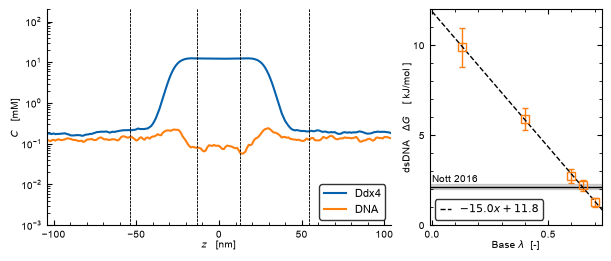

In [40]:
def load_data_ddx4_dsDNA():
    dG_list = []
    dG_err_list = []
    sdir = './analysis/data/'

    lambda_list = [0.13, 0.4, 0.6, 0.65, 0.7]
    for i,Lz_key in enumerate(['','_l04','_l06', '_l065', '_l07']):
        name = 'DDX4-400_dsACTG24-15{:s}'.format(Lz_key)

        # computr c_sat
        csat = np.load(sdir+"conc_"+name+"_dsACTG24.npy".format(key))

        rna_dens_mean = csat[2]*1e3
        rna_dens_std = csat[3]*1e3
        rna_dil_mean = csat[0]*1e3
        rna_dil_std = csat[1]*1e3

        RT = 8.31*1e-3 * 293
        dG = -np.log(rna_dens_mean/rna_dil_mean) * RT 
        dG_list.append(dG)
        dG_err = error_prop(rna_dens_mean,rna_dil_mean,rna_dens_std,rna_dil_std) * RT
        dG_err_list.append(dG_err)
        print(name, ":", dG, "pm", dG_err)
    return lambda_list, dG_list, dG_err_list

def load_linear_fit(lambda_list,dG_list):
    A = np.vstack([lambda_list, np.ones(len(lambda_list))]).T 
    a, b = np.linalg.lstsq(A, dG_list, rcond=None)[0]
    l_fit = (target_dG-b)/a
    print("lambda at target dG", l_fit)
    return a, b

def adjust_fig(ax__,param):
    [dx,dy,dw,dh] = param
    pos1 = ax__.get_position()  
    pos2 = [pos1.x0+dx, pos1.y0+dy, pos1.width+dw, pos1.height+dh] 
    ax__.set_position(pos2)
    
 

def plot_ddx4_dsdna_slab(axs):
    ax = axs[0]
    ddx4_dna_plot_density_profile(ax, name, 'DDX4', "", title_on=False) 
    ddx4_dna_plot_density_profile(ax, name, 'dsACTG24', "DDX4 (400)$-$dsDNA (15), l065", title_on=False)
    
    ax.legend(fontsize=8, edgecolor='k', loc="lower right")
    ax.set_xlabel("$z$   [nm]", labelpad=0.1)
    ax.set_ylabel("$C$   [mM]", labelpad=0.1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(top=False, right=False)
    ax.tick_params(axis="both", which="minor", top=False, right=False)
    ax.set_xticks(np.arange(-100,110,50)); ax.set_xticks(np.arange(-100,110,10),minor=True)
    
    ax = axs[1]
    ## exp data
    dG_exp = 1.9
    dG_exp_err = 0.4
    
    print("target dG", "{0} pm {1} kj/mol".format(target_dG, (target_dG_std)))
    ax.hlines(target_dG, -0.1, 0.73, color='black', linestyle='solid', lw=1)
    ax.axhspan(target_dG-target_dG_std, target_dG+target_dG_std, color='grey', alpha=0.3)
    
    ## simulation data
    lambda_list_dsDNA, dG_list_dsDNA, dG_err_list_dsDNA = load_data_ddx4_dsDNA()
    ax.errorbar(lambda_list_dsDNA, dG_list_dsDNA, yerr=dG_err_list_dsDNA,
                lw=0, marker='s', ms=6, elinewidth=1, capsize=2, capthick=1,
                markerfacecolor='none', color=cmap(1))
    
    
    a, b = load_linear_fit(lambda_list_dsDNA, dG_list_dsDNA) 
    ax.plot([0,1.13], [b, 1.13*a+b],
            color='k',linestyle="dashed", lw=1,
            label="${:s}x+{:s}$".format(str(a)[:5],str(b)[0:4]))
    
    
    ax.set_xlabel("Base $\lambda$  [-]", labelpad=0.1)
    ax.set_ylabel("dsDNA   $\Delta G$    [ kJ/mol ]", labelpad=0.1)
    
    ax.set_xticks(np.arange(-0,0.73,0.5)); ax.set_xticks(np.arange(0,0.73,0.1),minor=True)
    ax.set_yticks(np.arange(-0,12,5)); ax.set_yticks(np.arange(-2,12,1),minor=True)
    ax.set_xlim([-0.01,0.73])
    ax.set_ylim([-0,12])
    ax.text(0,2.4,"Nott 2016")
    
    ax.legend(edgecolor='k', fontsize=8, ncol=2, loc='lower left', handlelength=1.)
    #fig.set_constrained_layout_pads(w_pad=0.1, h_pad=0.05, wspace=0.15, hspace=0.0)
    
fig, axs = plt.subplots(1,2,figsize=(6, 2.5), constrained_layout=True, gridspec_kw={'width_ratios': [2, 1]})
plot_ddx4_dsdna_slab(axs)
plt.show()

target dG 2.13 pm 0.14 kj/mol
DDX4-400_dsACTG24-15 : 9.895754278894152 pm 1.0821366178403464
DDX4-400_dsACTG24-15_l04 : 5.928522154648137 pm 0.6108537936180305
DDX4-400_dsACTG24-15_l06 : 2.7366040974918744 pm 0.3795591723787062
DDX4-400_dsACTG24-15_l065 : 2.219773143737506 pm 0.314199810676043
DDX4-400_dsACTG24-15_l07 : 1.278649877873659 pm 0.24535414446509332
lambda at target dG 0.6474845627987902


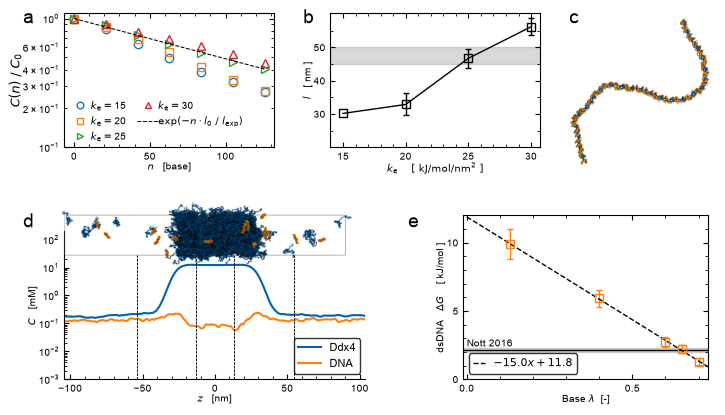

In [41]:
fig = plt.figure( figsize=(7, 4) )

#ax0 = fig.add_axes([0.06, 0.55, 0.42, 0.43])
#ax1 = fig.add_axes([0.57, 0.55, 0.42, 0.43])
ax0 = fig.add_axes([0.06, 0.65, 0.3, 0.335])
ax1 = fig.add_axes([0.44, 0.65, 0.3, 0.335])
plot_dan_onechain([ax0, ax1])

#ax2 = fig.add_axes([0.64, 0.52, 0.48, 0.48/887*835])
ax2 = fig.add_axes([0.7, 0.6, 0.37, 0.37*887/835])
img = mpimg.imread("./figdata/bp280_dna.png")
ax2.imshow(img)
ax2.axis("off")

ax3 = fig.add_axes([0.06, 0.07, 0.43, 0.37])
ax4 = fig.add_axes([0.63, 0.07, 0.35, 0.41])
plot_ddx4_dsdna_slab([ax3, ax4])

ax5 = fig.add_axes([-0.16, 0.32, 0.85, 0.85/2385*619])
img = mpimg.imread("./figdata/ddx4_dsdna_slab.png")
ax5.imshow(img)
ax5.axis("off")


fig.text(0.001, 0.96, "a", size=14)
fig.text(0.401, 0.96, "b", size=14)
fig.text(0.781, 0.96, "c", size=14)
fig.text(0.001, 0.45, "d", size=14)
fig.text(0.551, 0.45, "e", size=14)

plt.savefig("figure6.pdf", dpi=300)
plt.show()

# SASA computatoin

In [42]:
backbone_atom_names = ["P", "OP1", "OP2", 
                       "O5'", "C5'", "C4'", "O4'", "C3'", "O3'", "C2'", "O2'", "C1'",
                       "1H2'", "1H5'", "2H5'", "2HO'", "H1'", "H3'", "H4'"]

def compute_sasa_base(fn='../data/DNA/24bp_dsDNA/actg_bp24.pdb', probe_radius=0.14):
    # load traj
    traj = md.load(fn)

    # find base atoms
    base_ind = []
    top = traj.topology
    for i,atom in enumerate(top.atoms):
        if (atom.name not in backbone_atom_names) and (atom.element != md.element.hydrogen):
            print(atom.element)
            print("atom",atom.name, "; res",atom.residue)
            base_ind.append(i)
    print("==="*20)

    # compute sasa per residue
    sasa_per_atom = md.shrake_rupley(traj, mode="atom", probe_radius=probe_radius) # sasa per atom
    n_residues = traj.topology.n_residues
    sasa_per_residue = np.zeros((traj.n_frames, n_residues))
    for atom in traj.topology.atoms:
        sasa_per_residue[:, atom.residue.index] += sasa_per_atom[:, atom.index]

    print("==="*20)

    return sasa_per_residue

index_res = np.arange(1,24-1).tolist() + np.arange(1+24,24-1+24).tolist()
print(index_res)


[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46]


In [43]:
probe_radius = 0.5
sasa_dsRNA  = compute_sasa_base(fn='./sasa_data/acug_template_1.pdb', probe_radius=probe_radius)[0] # 24-bp dsRNA


nitrogen
atom N9 ; res A1
carbon
atom C8 ; res A1
nitrogen
atom N7 ; res A1
carbon
atom C5 ; res A1
carbon
atom C6 ; res A1
nitrogen
atom N6 ; res A1
nitrogen
atom N1 ; res A1
carbon
atom C2 ; res A1
nitrogen
atom N3 ; res A1
carbon
atom C4 ; res A1
nitrogen
atom N1 ; res C2
carbon
atom C6 ; res C2
carbon
atom C5 ; res C2
carbon
atom C4 ; res C2
nitrogen
atom N4 ; res C2
nitrogen
atom N3 ; res C2
carbon
atom C2 ; res C2
oxygen
atom O2 ; res C2
nitrogen
atom N1 ; res U3
carbon
atom C6 ; res U3
carbon
atom C5 ; res U3
carbon
atom C4 ; res U3
oxygen
atom O4 ; res U3
nitrogen
atom N3 ; res U3
carbon
atom C2 ; res U3
oxygen
atom O2 ; res U3
nitrogen
atom N9 ; res G4
carbon
atom C8 ; res G4
nitrogen
atom N7 ; res G4
carbon
atom C5 ; res G4
carbon
atom C6 ; res G4
oxygen
atom O6 ; res G4
nitrogen
atom N1 ; res G4
carbon
atom C2 ; res G4
nitrogen
atom N2 ; res G4
nitrogen
atom N3 ; res G4
carbon
atom C4 ; res G4
nitrogen
atom N9 ; res A5
carbon
atom C8 ; res A5
nitrogen
atom N7 ; res A5
carbon

In [44]:
probe_radius = 0.5
sasa_dsDNA  = compute_sasa_base(fn='./sasa_data/actg_bp24.pdb', probe_radius=probe_radius)[0] # 24-bp dsDNA

nitrogen
atom N9 ; res A1
carbon
atom C8 ; res A1
nitrogen
atom N7 ; res A1
carbon
atom C5 ; res A1
carbon
atom C6 ; res A1
nitrogen
atom N6 ; res A1
nitrogen
atom N1 ; res A1
carbon
atom C2 ; res A1
nitrogen
atom N3 ; res A1
carbon
atom C4 ; res A1
nitrogen
atom N1 ; res C2
carbon
atom C2 ; res C2
oxygen
atom O2 ; res C2
nitrogen
atom N3 ; res C2
carbon
atom C4 ; res C2
nitrogen
atom N4 ; res C2
carbon
atom C5 ; res C2
carbon
atom C6 ; res C2
nitrogen
atom N1 ; res T3
carbon
atom C2 ; res T3
oxygen
atom O2 ; res T3
nitrogen
atom N3 ; res T3
carbon
atom C4 ; res T3
oxygen
atom O4 ; res T3
carbon
atom C5 ; res T3
carbon
atom C7 ; res T3
carbon
atom C6 ; res T3
nitrogen
atom N9 ; res G4
carbon
atom C8 ; res G4
nitrogen
atom N7 ; res G4
carbon
atom C5 ; res G4
carbon
atom C6 ; res G4
oxygen
atom O6 ; res G4
nitrogen
atom N1 ; res G4
carbon
atom C2 ; res G4
nitrogen
atom N2 ; res G4
nitrogen
atom N3 ; res G4
carbon
atom C4 ; res G4
nitrogen
atom N9 ; res A5
carbon
atom C8 ; res A5
nitrogen

total sasa RNA 1.6724291690307753
total sasa DNA 2.111601419545795


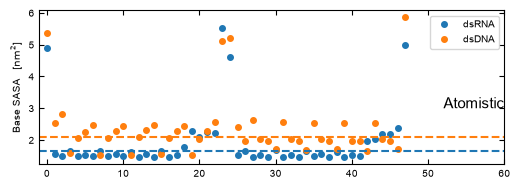

In [45]:
# RNA, acug
# DNA, actg
fig, ax = plt.subplots(1, 1, figsize=(6,2))

ax.plot(sasa_dsRNA, label="dsRNA", marker='o', lw=0, markersize=4) 
ax.plot(sasa_dsDNA, label="dsDNA", marker='o', lw=0, markersize=4)

print("total sasa RNA", sasa_dsRNA[index_res].mean()) 
print("total sasa DNA", sasa_dsDNA[index_res].mean()) 

ax.set_ylabel(r"Base SASA   [$\mathrm{nm^2}$]")
ax.set_xlim([-1,60])
ax.text(52, 3, "Atomistic", fontsize=11)
plt.legend()

plt.hlines(1.67, -1, 60, color=cmap(0), linestyle="dashed")
plt.hlines(2.11, -1, 60, color=cmap(1), linestyle="dashed")


plt.savefig("sasa_atomistic.pdf", dpi=300)
plt.show()

In [46]:
from mdtraj.core.element import Element
from mdtraj.core.topology import Topology


def load_cg_traj(fn='../data/DNA/24bp_dsDNA/actg_bp24.pdb'):
    traj = md.load(fn)
    n_residues = traj.n_residues
 
    top = traj.topology
    pos = []
    for i,atom in enumerate(top.atoms):
        # backbone
        if atom.name =="P":
            pos.append(traj.xyz[0,i,:])
            print("atom.residue.name", atom.residue.name, ": atom.name", atom, "added")
        # base
        if atom.residue.name in ['U','C','T', 'DC', 'DT']:
            #print(atom.name)
            if atom.name == 'N1':
                pos.append(traj.xyz[0,i,:])
                print("atom.residue.name", atom.residue.name, ": atom.name", atom, "added")

        elif atom.residue.name in ['A','G', 'DA', 'DG']:
            if atom.name == 'N9':
                pos.append(traj.xyz[0,i,:])
                print("atom.residue.name", atom.residue.name, ": atom.name", atom, "added")

    pos = np.array(pos).reshape(1, -1, 3)

    # make topology
    elem_P = Element.getBySymbol('Ar') # backbone
    elem_B = Element.getBySymbol('Kr') # base
    top_new = Topology()
    chain = top_new.add_chain()
    for i in range(n_residues):
        res = top_new.add_residue(f'NT{i}', chain)
        top_new.add_atom('P', elem_P, res)   # backbone bead
        top_new.add_atom('B', elem_B, res)   # base bead

    return md.Trajectory(pos, top_new)
 

def comput_sasa_cgtraj(traj, probe_radius=0.14):
    sigma_P = 0.6954  # nm
    sigma_B = 0.6238  # nm
    sasa = md.shrake_rupley(
        traj,
        mode='atom',
        change_radii={"Ar": sigma_P / 2, "Kr": sigma_B / 2},
        probe_radius = probe_radius
    )
    return sasa


In [47]:
probe_radius = 0.5
t_dna_cg = load_cg_traj(fn='sasa_data/actg_bp24.pdb')
sasa_dna_cg = comput_sasa_cgtraj(t_dna_cg, probe_radius=probe_radius)

atom.residue.name A : atom.name A1-P added
atom.residue.name A : atom.name A1-N9 added
atom.residue.name C : atom.name C2-P added
atom.residue.name C : atom.name C2-N1 added
atom.residue.name T : atom.name T3-P added
atom.residue.name T : atom.name T3-N1 added
atom.residue.name G : atom.name G4-P added
atom.residue.name G : atom.name G4-N9 added
atom.residue.name A : atom.name A5-P added
atom.residue.name A : atom.name A5-N9 added
atom.residue.name C : atom.name C6-P added
atom.residue.name C : atom.name C6-N1 added
atom.residue.name T : atom.name T7-P added
atom.residue.name T : atom.name T7-N1 added
atom.residue.name G : atom.name G8-P added
atom.residue.name G : atom.name G8-N9 added
atom.residue.name A : atom.name A9-P added
atom.residue.name A : atom.name A9-N9 added
atom.residue.name C : atom.name C10-P added
atom.residue.name C : atom.name C10-N1 added
atom.residue.name T : atom.name T11-P added
atom.residue.name T : atom.name T11-N1 added
atom.residue.name G : atom.name G12-P a

In [48]:
probe_radius = 0.5
t_rna_cg = load_cg_traj(fn='./sasa_data/acug_template_1.pdb')
sasa_rna_cg = comput_sasa_cgtraj(t_rna_cg, probe_radius=probe_radius)

atom.residue.name A : atom.name A1-P added
atom.residue.name A : atom.name A1-N9 added
atom.residue.name C : atom.name C2-P added
atom.residue.name C : atom.name C2-N1 added
atom.residue.name U : atom.name U3-P added
atom.residue.name U : atom.name U3-N1 added
atom.residue.name G : atom.name G4-P added
atom.residue.name G : atom.name G4-N9 added
atom.residue.name A : atom.name A5-P added
atom.residue.name A : atom.name A5-N9 added
atom.residue.name C : atom.name C6-P added
atom.residue.name C : atom.name C6-N1 added
atom.residue.name U : atom.name U7-P added
atom.residue.name U : atom.name U7-N1 added
atom.residue.name G : atom.name G8-P added
atom.residue.name G : atom.name G8-N9 added
atom.residue.name A : atom.name A9-P added
atom.residue.name A : atom.name A9-N9 added
atom.residue.name C : atom.name C10-P added
atom.residue.name C : atom.name C10-N1 added
atom.residue.name U : atom.name U11-P added
atom.residue.name U : atom.name U11-N1 added
atom.residue.name G : atom.name G12-P a

total sasa RNA 0.36201182
total sasa DNA 0.086875


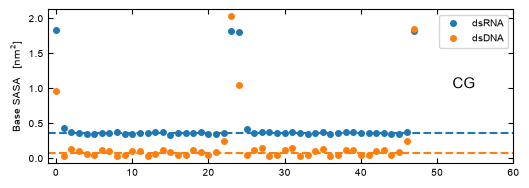

In [49]:
# RNA, acug
# DNA, actg
fig, ax = plt.subplots(1, 1, figsize=(6,2))

ax.plot(sasa_rna_cg[0, 1::2], label="dsRNA", marker='o', lw=0, markersize=4) 
ax.plot(sasa_dna_cg[0, 1::2], label="dsDNA", marker='o', lw=0, markersize=4)

print("total sasa RNA", sasa_rna_cg[0, 1::2][index_res].mean()) 
print("total sasa DNA", sasa_dna_cg[0, 1::2][index_res].mean()) 

ax.set_ylabel(r"Base SASA   [$\mathrm{nm^2}$]")
ax.set_xlim([-1,60])
ax.text(52, 1, "CG", fontsize=11)
plt.legend()

plt.hlines(0.36, -1, 60, color=cmap(0), linestyle="dashed")
plt.hlines(0.08, -1, 60, color=cmap(1), linestyle="dashed")
plt.savefig("sasa_cg.pdf", dpi=300)

plt.show()

atomistic sasa RNA 1.6724291690307753
atomistic sasa DNA 2.111601419545795
CG sasa RNA 0.36201182
CG sasa DNA 0.086875


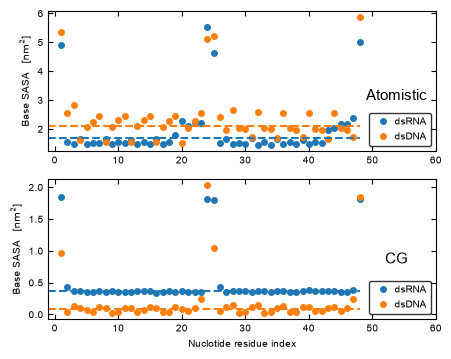

In [50]:
fig, axs = plt.subplots(2, 1, figsize=(5,4))

# Atomistic 
ax = axs[0]
ax.plot(np.arange(1,48+1), sasa_dsRNA, label="dsRNA", marker='o', lw=0, markersize=4) 
ax.plot(np.arange(1,48+1), sasa_dsDNA, label="dsDNA", marker='o', lw=0, markersize=4)

ax.set_ylabel(r"Base SASA   [$\mathrm{nm^2}$]")
ax.set_xlim([-1,60])
ax.text(49, 3, "Atomistic", fontsize=11)
ax.legend(edgecolor='k', loc="lower right", handletextpad=0.1)

ax.hlines(1.67, -1, 48, color=cmap(0), linestyle="dashed")
ax.hlines(2.11, -1, 48, color=cmap(1), linestyle="dashed")

print("atomistic sasa RNA", sasa_dsRNA[index_res].mean()) 
print("atomistic sasa DNA", sasa_dsDNA[index_res].mean()) 


# CG 
ax = axs[1]
ax.plot(np.arange(1,48+1), sasa_rna_cg[0, 1::2], label="dsRNA", marker='o', lw=0, markersize=4) 
ax.plot(np.arange(1,48+1), sasa_dna_cg[0, 1::2], label="dsDNA", marker='o', lw=0, markersize=4)

print("CG sasa RNA", sasa_rna_cg[0, 1::2][index_res].mean()) 
print("CG sasa DNA", sasa_dna_cg[0, 1::2][index_res].mean()) 

ax.set_ylabel(r"Base SASA   [$\mathrm{nm^2}$]")
ax.set_xlabel("Nuclotide residue index")
ax.set_xlim([-1,60])
ax.text(52, 0.8, "CG", fontsize=11)
ax.legend(edgecolor='k', loc="lower right", handletextpad=0.1)

ax.hlines(0.36, -1, 48, color=cmap(0), linestyle="dashed")
ax.hlines(0.08, -1, 48, color=cmap(1), linestyle="dashed")

plt.savefig("sasa_atomistic_cg.pdf", dpi=300, bbox_inches='tight')
plt.savefig("sasa_atomistic_cg.svg", dpi=300, bbox_inches='tight')
plt.show()